In [1]:
# Import Libraries
import subprocess, sys
pkgs = ['pyreadstat','pandas','numpy','scikit-learn','xgboost',
'shap','imbalanced-learn','matplotlib','seaborn',
'scipy','statsmodels','openpyxl']
for p in pkgs:
    subprocess.check_call([sys.executable,'-m','pip','install',p,'--quiet'])

import warnings; warnings.filterwarnings('ignore')
import os, pickle, json
import pandas as pd
import numpy as np
import pyreadstat
import matplotlib.pyplot as plt; plt.rcParams['figure.dpi']=150
import seaborn as sns
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (RepeatedStratifiedKFold,
    RandomizedSearchCV, cross_val_predict, cross_validate)
from sklearn.metrics import (roc_auc_score, average_precision_score,
    f1_score, accuracy_score, brier_score_loss,
    confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.calibration import calibration_curve
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from statsmodels.stats.outliers_influence import variance_inflation_factor
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
print('All libraries loaded.')


All libraries loaded.


In [2]:
# Define file paths and output folder
NDHS_2018_PATH = "path/to/your/NDHS_IR_file.dta"  # Replace with actual file path'
NDHS_2024_PATH = "path/to/your/NDHS_IR_file.dta"  # Replace with actual file path'
OUTPUTS        = 'outputs'

os.makedirs(OUTPUTS, exist_ok=True)

for path, label in [(NDHS_2018_PATH,'2018'),(NDHS_2024_PATH,'2024')]:
    print(f'  {label}: {"FOUND" if os.path.exists(path) else "NOT FOUND"}')
print(f'  Outputs folder: {os.path.abspath(OUTPUTS)}')
print(f'  Working directory: {os.getcwd()}')


  2018: FOUND
  2024: FOUND
  Outputs folder: C:\Users\USER\outputs
  Working directory: C:\Users\USER


In [3]:
VARS = ['v000','v001','v002','v003','v005','v012','v021','v022','v023','v024',
'v025','v106','v130','v136','v151','v157','v158','v159','v190',
'v201','v213','v301','v501','v714']
df18_raw,_ = pyreadstat.read_dta(NDHS_2018_PATH,usecols=VARS,apply_value_formats=False)
df18_raw.columns = df18_raw.columns.str.lower()
print(f'2018 raw: {df18_raw.shape}')


2018 raw: (41821, 24)


In [4]:
df24_raw,_ = pyreadstat.read_dta(NDHS_2024_PATH,usecols=VARS,apply_value_formats=False)
df24_raw.columns = df24_raw.columns.str.lower()
print(f'2024 raw: {df24_raw.shape}')


2024 raw: (39050, 24)


In [5]:
df18 = df18_raw[df18_raw['v012'].between(15,19)].copy().reset_index(drop=True)
df24 = df24_raw[df24_raw['v012'].between(15,19)].copy().reset_index(drop=True)
print(f'2018 adolescents: {len(df18):,} | 2024 adolescents: {len(df24):,}')


2018 adolescents: 8,423 | 2024 adolescents: 7,995


In [6]:
def make_outcome(df):
    d = df.copy()
    born     = d['v201'].fillna(0) >= 1
    pregnant = d['v213'].isin([1])
    d['childbearing'] = ((born) | (pregnant)).astype(int)
    missing  = d['v201'].isna() & d['v213'].isna()
    d.loc[missing,'childbearing'] = np.nan
    return d

df18 = make_outcome(df18)
df24 = make_outcome(df24)

# Also create outcome EXCLUDING currently pregnant (sensitivity analysis)
def make_outcome_births_only(df):
    d = df.copy()
    d['childbearing_births'] = (d['v201'].fillna(0) >= 1).astype(int)
    d.loc[d['v201'].isna(),'childbearing_births'] = np.nan
    return d

df18 = make_outcome_births_only(df18)
df24 = make_outcome_births_only(df24)

for yr,df in [('2018',df18),('2024',df24)]:
    n    = df['childbearing'].notna().sum()
    prev = df['childbearing'].mean()*100
    nb   = df['childbearing_births'].mean()*100
    print(f'{yr}: n={n:,} | prevalence (incl.pregnant)={prev:.1f}% | births-only={nb:.1f}%')



2018: n=8,423 | prevalence (incl.pregnant)=18.2% | births-only=14.2%
2024: n=7,995 | prevalence (incl.pregnant)=12.8% | births-only=10.1%


In [7]:
# VERIFY ZONE_MAP against data dictionaries for BOTH rounds
ZONE_MAP = {
    1: 'NC',
    2: 'NE',
    3: 'NW',
    4: 'SE',
    5: 'SS',
    6: 'SW'
}

def recode(df):
    d = df.copy()
    d['weight']    = d['v005']/1_000_000
    d['age']       = d['v012'].astype(float)
    d['education'] = d['v106'].map({0:'None',1:'Primary',2:'Secondary',3:'Higher'})
    d['marital']   = d['v501'].map({0:'Never',1:'Married',2:'Living_together',
        3:'Widowed',4:'Divorced',5:'Separated'}).apply(
        lambda x: 'Currently_union' if x in ['Married','Living_together']
                  else ('Never' if x=='Never' else 'Formerly') if pd.notna(x) else np.nan)
    d['employed']  = d['v714'].map({0:0,1:1,7:np.nan,8:np.nan})
    d['contra_know']= d['v301'].apply(
        lambda x: 0 if x==0 else (1 if pd.notna(x) and x>0 else np.nan))
    def media(row):
        score=0
        for v in ['v157','v158','v159']:
            val=row.get(v,np.nan)
            if val==1: score+=1
            elif pd.isna(val): return np.nan
        return score
    d['media']     = d.apply(media,axis=1)
    d['religion']  = d['v130'].map({1:'Christianity',2:'Islam',
        3:'Other',4:'Other',5:'Other',6:'Other',96:'Other'})
    d['wealth']    = d['v190'].map({1:'Poorest',2:'Poorer',3:'Middle',
        4:'Richer',5:'Richest'})
    d['hh_size']   = d['v136'].astype(float)
    d['hh_head_sex']= d['v151'].map({1:'Male',2:'Female'})
    d['residence'] = d['v025'].map({1:'Urban',2:'Rural'})
    d['zone']      = d['v024'].map(ZONE_MAP)
    return d

df18 = recode(df18)
df24 = recode(df24)
print('Recoding complete.')
print('2018 zone distribution:'); print(df18['zone'].value_counts())


Recoding complete.
2018 zone distribution:
zone
NW    2253
NE    1661
NC    1597
SE    1066
SS     929
SW     917
Name: count, dtype: int64


In [8]:
FEATURES = ['age','education','marital','employed','contra_know',
'media','religion','wealth','hh_size','hh_head_sex',
'residence','zone']

print(f"{'Variable':<22}{'2018 miss%':>12}{'2024 miss%':>12}{'Status':>10}")
print('-'*58)
EXCLUDE=[]
for f in FEATURES:
    m18=df18[f].isna().mean()*100
    m24=df24[f].isna().mean()*100
    ok = m18<=20 and m24<=20
    if not ok: EXCLUDE.append(f)
    print(f"{f:<22}{m18:>11.1f}%{m24:>11.1f}%{'OK' if ok else 'EXCLUDE':>10}")

FEATURES_FINAL=[f for f in FEATURES if f not in EXCLUDE]
print(f'\nFinal features ({len(FEATURES_FINAL)}): {FEATURES_FINAL}')

audit=pd.DataFrame({'variable':FEATURES,
'miss_2018':[df18[f].isna().mean()*100 for f in FEATURES],
'miss_2024':[df24[f].isna().mean()*100 for f in FEATURES],
'status':['EXCLUDE' if f in EXCLUDE else 'OK' for f in FEATURES]})
audit.to_csv(f'{OUTPUTS}/harmonisation_audit.csv',index=False)
print('Saved: harmonisation_audit.csv')


Variable                2018 miss%  2024 miss%    Status
----------------------------------------------------------
age                           0.0%        0.0%        OK
education                     0.0%        0.0%        OK
marital                       0.0%        0.0%        OK
employed                      0.0%        0.0%        OK
contra_know                   0.0%        0.0%        OK
media                         0.0%        0.0%        OK
religion                      0.0%        0.0%        OK
wealth                        0.0%        0.0%        OK
hh_size                       0.0%        0.0%        OK
hh_head_sex                   0.0%        0.0%        OK
residence                     0.0%        0.0%        OK
zone                          0.0%        0.0%        OK

Final features (12): ['age', 'education', 'marital', 'employed', 'contra_know', 'media', 'religion', 'wealth', 'hh_size', 'hh_head_sex', 'residence', 'zone']
Saved: harmonisation_audit.csv


In [9]:
# Drop missing outcome
TARGET = 'childbearing'

df18_c = df18[df18[TARGET].notna()].copy().reset_index(drop=True)
df24_c = df24[df24[TARGET].notna()].copy().reset_index(drop=True)
print(f'After dropping missing outcome — 2018: {len(df18_c):,} | 2024: {len(df24_c):,}')

# One-hot encode categoricals — keep NaN as NaN (Pipeline imputer handles them)
CAT_COLS=[c for c in ['education','marital','religion','wealth',
'hh_head_sex','residence','zone'] if c in FEATURES_FINAL]
NUM_COLS=[c for c in ['age','employed','contra_know','media','hh_size'] if c in FEATURES_FINAL]
KEEP    = NUM_COLS + CAT_COLS

X18_raw=pd.get_dummies(df18_c[KEEP],columns=CAT_COLS,drop_first=False,dtype=float)
X24_raw=pd.get_dummies(df24_c[KEEP],columns=CAT_COLS,drop_first=False,dtype=float)

# Align: ensure both matrices have identical columns
X18_raw,X24_raw = X18_raw.align(X24_raw,join='outer',axis=1,fill_value=0)
FEATURE_NAMES = X18_raw.columns.tolist()
print(f'Feature columns: {len(FEATURE_NAMES)}')

y18 = df18_c[TARGET].astype(int).values
y24 = df24_c[TARGET].astype(int).values
w18 = df18_c['weight'].values
w24 = df24_c['weight'].values

# Births-only sensitivity outcome
df18_c2 = df18[df18['childbearing_births'].notna()].copy().reset_index(drop=True)
X18_births,_ = pd.get_dummies(df18_c2[KEEP],columns=CAT_COLS,
                               drop_first=False,dtype=float).align(
               X18_raw,join='right',axis=1,fill_value=0)
y18_births = df18_c2['childbearing_births'].astype(int).values
w18_births = df18_c2['weight'].values

X18_raw.to_csv(f'{OUTPUTS}/X18_raw.csv',index=False)
X24_raw.to_csv(f'{OUTPUTS}/X24_raw.csv',index=False)
print('Saved: X18_raw.csv, X24_raw.csv')


After dropping missing outcome — 2018: 8,423 | 2024: 7,995
Feature columns: 30
Saved: X18_raw.csv, X24_raw.csv


In [10]:
# Sociodemographic characteristics

from scipy.stats import chi2_contingency
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter


# Step 1: Add derived variables 
def add_t1_vars(df):
    d = df.copy()
    d['age_grp']      = pd.cut(d['age'], bins=[14,16,18,19],
                          labels=['15-16','17-18','19'],
                          include_lowest=True).astype(str)
    d['employed_cat'] = d['employed'].map({1:'Employed', 0:'Not employed'})
    d['contra_cat']   = d['contra_know'].map({1:'Yes', 0:'No'})
    return d

df18_t = add_t1_vars(df18_c)
df24_t = add_t1_vars(df24_c)


# Step 2: Variable definitions 
TABLE1_VARS = [
    ('Age group',             'age_grp',
        ['15-16','17-18','19']),
    ('Educational attainment','education',
        ['None','Primary','Secondary','Higher']),
    ('Marital status',        'marital',
        ['Never','Currently_union','Formerly']),
    ('Place of residence',    'residence',
        ['Urban','Rural']),
    ('Geopolitical zone',     'zone',
        ['NC','NE','NW','SE','SS','SW']),
    ('Wealth index quintile', 'wealth',
        ['Poorest','Poorer','Middle','Richer','Richest']),
    ('Employment status',     'employed_cat',
        ['Employed','Not employed']),
    ('Contraceptive knowledge','contra_cat',
        ['Yes','No']),
    ('Religion',              'religion',
        ['Christianity','Islam','Other']),
    ('Sex of household head', 'hh_head_sex',
        ['Male','Female']),
]


# Step 3: Helper functions 
def wpct(df, var, cat, w='weight'):
    """Survey-weighted % and unweighted n."""
    sub = df[[var, w]].dropna()
    tot = sub[w].sum()
    cw  = sub.loc[sub[var]==cat, w].sum()
    n   = int((sub[var]==cat).sum())
    pct = cw / tot * 100 if tot > 0 else 0
    return f'{pct:.1f} ({n:,})'

def chi2p(df, var, outcome='childbearing'):
    """Chi-square p-value."""
    sub = df[[var, outcome]].dropna()
    ct  = pd.crosstab(sub[var], sub[outcome])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return '—'
    _, p, _, _ = chi2_contingency(ct)
    return '<0.001' if p < 0.001 else f'{p:.3f}'


#  Step 4: Build rows 
rows = []

n18  = len(df18_t);  n24  = len(df24_t)
cb18 = int((df18_t['childbearing']==1).sum())
no18 = int((df18_t['childbearing']==0).sum())
cb24 = int((df24_t['childbearing']==1).sum())

prev18w = np.average(df18_t['childbearing'],
                     weights=df18_t['weight']) * 100
prev24w = np.average(df24_t['childbearing'],
                     weights=df24_t['weight']) * 100

# Total row
rows.append({
'Variable'          : 'Total',
'Category'          : '',
'2018 Overall % (n)': f'— ({n18:,})',
'2018 No CB % (n)'  : f'— ({no18:,})',
'2018 Yes CB % (n)' : f'— ({cb18:,})',
'p-value'           : '',
'2024 Overall % (n)': f'— ({n24:,})',
})

# Prevalence row
rows.append({
'Variable'          : 'Adolescent childbearing',
'Category'          : 'Yes (prevalence)',
'2018 Overall % (n)': f'{prev18w:.1f} ({cb18:,})',
'2018 No CB % (n)'  : '—',
'2018 Yes CB % (n)' : '—',
'p-value'           : '—',
'2024 Overall % (n)': f'{prev24w:.1f} ({cb24:,})',
})

# Predictor rows
for label, var, cats in TABLE1_VARS:
    if var not in df18_t.columns:
        continue
    # Section header
    rows.append({
'Variable'          : label,
'Category'          : '',
'2018 Overall % (n)': '',
'2018 No CB % (n)'  : '',
'2018 Yes CB % (n)' : '',
'p-value'           : chi2p(df18_t, var),
'2024 Overall % (n)': '',
    })
    # Category rows
    for cat in cats:
        rows.append({
'Variable'          : '',
'Category'          : f'  {cat}',
'2018 Overall % (n)': wpct(df18_t, var, cat),
'2018 No CB % (n)'  : wpct(
                df18_t[df18_t['childbearing']==0], var, cat),
'2018 Yes CB % (n)' : wpct(
                df18_t[df18_t['childbearing']==1], var, cat),
'p-value'           : '',
'2024 Overall % (n)': wpct(df24_t, var, cat)
                if var in df24_t.columns else '—',
        })

t1_df = pd.DataFrame(rows)


# Step 5: Export to Excel 
outpath = f'{OUTPUTS}/Table1_Sociodemographic.xlsx'

with pd.ExcelWriter(outpath, engine='openpyxl') as writer:
    t1_df.to_excel(writer, sheet_name='Table1', index=False)
    ws  = writer.sheets['Table1']

    # Column widths
    for i, w_ in enumerate([30, 22, 20, 20, 20, 10, 20], 1):
        ws.column_dimensions[get_column_letter(i)].width = w_

    # Styles
    hdr_fill = PatternFill('solid', fgColor='1F4E79')
    sec_fill = PatternFill('solid', fgColor='D9E1F2')
    alt_fill = PatternFill('solid', fgColor='F5F8FF')
    thin     = Side(style='thin', color='AAAAAA')
    brd      = Border(top=thin, bottom=thin,
                      left=thin, right=thin)

    for ri_, row in enumerate(ws.iter_rows(), 1):
        for cell in row:
            cell.alignment = Alignment(
                wrap_text=True, vertical='center')
            cell.border = brd
            if ri_ == 1:
                cell.font = Font(
                    bold=True, color='FFFFFF', size=10)
                cell.fill = hdr_fill
            elif (cell.column == 1
                  and cell.value
                  and str(cell.value) not in
                  ['', 'Total', 'Adolescent childbearing']):
                cell.font = Font(bold=True, size=10)
                cell.fill = sec_fill
            elif ri_ in [2, 3]:
                cell.font = Font(bold=True, size=10)
            elif ri_ % 2 == 0:
                cell.font = Font(size=10)
                cell.fill = alt_fill
            else:
                cell.font = Font(size=10)

    ws.freeze_panes  = 'A2'
    ws.row_dimensions[1].height = 32

print(f'Table 1 saved: {outpath}')
print(f'Total rows: {len(t1_df)}')
print()
print('Preview (Variable | Category | 2018 Overall | p-value):')
print(t1_df[['Variable','Category',
'2018 Overall % (n)','p-value']].to_string(index=False))


Table 1 saved: outputs/Table1_Sociodemographic.xlsx
Total rows: 44

Preview (Variable | Category | 2018 Overall | p-value):
               Variable          Category 2018 Overall % (n) p-value
                  Total                            — (8,423)        
Adolescent childbearing  Yes (prevalence)       18.7 (1,534)       —
              Age group                                       <0.001
                                    15-16       43.4 (3,668)        
                                    17-18       41.4 (3,511)        
                                       19       15.2 (1,244)        
 Educational attainment                                       <0.001
                                     None       25.8 (2,096)        
                                  Primary         10.4 (908)        
                                Secondary       61.1 (5,229)        
                                   Higher          2.6 (190)        
         Marital status                         

In [11]:
# VIF check for multicollinearity
X18_vif = X18_raw.dropna()

vif_rows=[]
for i,col in enumerate(FEATURE_NAMES):
    try:
        vif = variance_inflation_factor(X18_vif.values.astype(float), i)
    except Exception:
        vif = np.nan
    vif_rows.append({'feature':col,'VIF':round(vif,2)})

vif_df = pd.DataFrame(vif_rows).sort_values('VIF',ascending=False)
high_vif = vif_df[vif_df['VIF']>10]
vif_df.to_csv(f'{OUTPUTS}/vif_check.csv',index=False)

print('VIF Results (top 20):')
print(vif_df.head(20).to_string(index=False))
if len(high_vif):
    print(f'\n HIGH VIF (>10) — consider exclusion: {high_vif["feature"].tolist()}')
else:
    print('\nAll VIF ≤ 10. No multicollinearity concern.')
print('Saved: vif_check.csv')


VIF Results (top 20):
              feature  VIF
        wealth_Middle  inf
        wealth_Poorer  inf
              zone_SS  inf
              zone_SE  inf
              zone_NW  inf
              zone_NE  inf
              zone_NC  inf
      residence_Urban  inf
      residence_Rural  inf
     hh_head_sex_Male  inf
   hh_head_sex_Female  inf
       wealth_Richest  inf
        wealth_Richer  inf
       wealth_Poorest  inf
              zone_SW  inf
       religion_Other  inf
       religion_Islam  inf
religion_Christianity  inf
        marital_Never  inf
     marital_Formerly  inf

 HIGH VIF (>10) — consider exclusion: ['wealth_Middle', 'wealth_Poorer', 'zone_SS', 'zone_SE', 'zone_NW', 'zone_NE', 'zone_NC', 'residence_Urban', 'residence_Rural', 'hh_head_sex_Male', 'hh_head_sex_Female', 'wealth_Richest', 'wealth_Richer', 'wealth_Poorest', 'zone_SW', 'religion_Other', 'religion_Islam', 'religion_Christianity', 'marital_Never', 'marital_Formerly', 'marital_Currently_union', 'education_Se

In [12]:
# Weighted descriptive analysis
def wprev(df,tgt,wcol='weight'):
    v=df[[tgt,wcol]].dropna()
    return round(np.average(v[tgt],weights=v[wcol])*100,1), len(v)

def strat(df,var,tgt='childbearing',wcol='weight'):
    rows=[]
    for val in sorted(df[var].dropna().unique()):
        sub=df[df[var]==val]
        pv,n=wprev(sub,tgt,wcol)
        rows.append({'stratum':var,'category':val,'prevalence_%':pv,'n':n})
    return pd.DataFrame(rows)

prev18,n18=wprev(df18_c,'childbearing')
prev24,n24=wprev(df24_c,'childbearing')
print(f'2018: {prev18}% (n={n18:,}) | 2024: {prev24}% (n={n24:,})')

strat_all=[]
for var in ['zone','residence','wealth','education','marital']:
    for yr,df in [('2018',df18_c),('2024',df24_c)]:
        res=strat(df,var); res['year']=yr
        strat_all.append(res)

strat_df=pd.concat(strat_all,ignore_index=True)
strat_df.to_csv(f'{OUTPUTS}/stratified_prevalence.csv',index=False)
print(strat_df.to_string(index=False))


2018: 18.7% (n=8,423) | 2024: 13.8% (n=7,995)
  stratum        category  prevalence_%    n year
     zone              NC          16.3 1597 2018
     zone              NE          24.5 1661 2018
     zone              NW          28.5 2253 2018
     zone              SE           8.8 1066 2018
     zone              SS          10.6  929 2018
     zone              SW           5.5  917 2018
     zone              NC          21.5 2122 2024
     zone              NE          17.2 1291 2024
     zone              NW          11.1 1546 2024
     zone              SE           4.8  971 2024
     zone              SS           6.1 1065 2024
     zone              SW           5.0 1000 2024
residence           Rural          27.2 5047 2018
residence           Urban           8.4 3376 2018
residence           Rural          21.9 4055 2024
residence           Urban           5.5 3940 2024
   wealth          Middle          19.4 1905 2018
   wealth          Poorer          31.0 1783 2018
   w

In [13]:
# Survey-weighted bivariate tests

from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency

chi2_rows=[]
STRAT_VARS=['zone','residence','wealth','education',
'marital','employed','contra_know','religion','hh_head_sex']

for var in STRAT_VARS:
    sub = df18_c[[var,'childbearing','weight']].dropna()
    # Weighted crosstab
    ct_w = sub.pivot_table(index=var,columns='childbearing',
                            values='weight',aggfunc='sum').fillna(0)
    # Rao-Scott approximation: scale effective sample size by DEFF
    # Conservative: use unweighted n with design effect correction note
    ct_n = pd.crosstab(sub[var],sub['childbearing'])
    chi2,p,dof,_ = chi2_contingency(ct_n)
    chi2_rows.append({'variable':var,'chi2_unweighted':round(chi2,2),
'df':dof,'p_value':round(p,4),
'note':'Unweighted used; DHS design effect not fully corrected'})

chi2_df=pd.DataFrame(chi2_rows)
chi2_df.to_csv(f'{OUTPUTS}/bivariate_chi2_2018.csv',index=False)
print(chi2_df.to_string(index=False))
print('\nNote: Full Rao-Scott correction requires svy package (R). Results are indicative.')
print('Saved: bivariate_chi2_2018.csv')


   variable  chi2_unweighted  df  p_value                                                   note
       zone           349.90   5   0.0000 Unweighted used; DHS design effect not fully corrected
  residence           315.53   1   0.0000 Unweighted used; DHS design effect not fully corrected
     wealth           554.05   4   0.0000 Unweighted used; DHS design effect not fully corrected
  education          1135.31   3   0.0000 Unweighted used; DHS design effect not fully corrected
    marital          5004.92   2   0.0000 Unweighted used; DHS design effect not fully corrected
   employed             9.02   1   0.0027 Unweighted used; DHS design effect not fully corrected
contra_know            64.04   1   0.0000 Unweighted used; DHS design effect not fully corrected
   religion           290.93   2   0.0000 Unweighted used; DHS design effect not fully corrected
hh_head_sex            83.71   1   0.0000 Unweighted used; DHS design effect not fully corrected

Note: Full Rao-Scott correcti

In [14]:
# Check class imbalance

unique,counts = np.unique(y18,return_counts=True)
print(f'Class distribution: {dict(zip(unique,counts))}')
minority_pct = counts.min()/counts.sum()*100
print(f'Minority class: {minority_pct:.1f}%')
USE_SMOTE = minority_pct < 40
print(f'SMOTE will be evaluated in pipelines: {USE_SMOTE}')


Class distribution: {np.int64(0): np.int64(6889), np.int64(1): np.int64(1534)}
Minority class: 18.2%
SMOTE will be evaluated in pipelines: True


In [15]:
# Build pipelines and fit logistic regression

cv = RepeatedStratifiedKFold(n_splits=5,n_repeats=3,random_state=42)

imputer = IterativeImputer(max_iter=10,random_state=42)
scaler  = StandardScaler()

lr_pipeline = Pipeline([
    ('imputer'   , IterativeImputer(max_iter=10,random_state=42)),
    ('scaler'    , StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000,random_state=42))
])

lr_param_grid = {'classifier__C':[0.001,0.01,0.1,1,10,100]}
lr_search = RandomizedSearchCV(
    lr_pipeline, lr_param_grid, n_iter=6, cv=cv,
    scoring='roc_auc', n_jobs=-1, random_state=42)
lr_search.fit(X18_raw.values, y18,
              classifier__sample_weight=w18)
best_lr = lr_search.best_estimator_

print(f'Best LR C: {lr_search.best_params_}')
with open(f'{OUTPUTS}/best_lr.pkl','wb') as f: pickle.dump(best_lr,f)
print('Saved: best_lr.pkl')


Best LR C: {'classifier__C': 0.1}
Saved: best_lr.pkl


In [17]:
# Random forest pipeline

rf_param_dist = {
'classifier__n_estimators'    :[100,200,300,500],
'classifier__max_depth'       :[None,5,10,15,20],
'classifier__min_samples_leaf':[1,2,5,10],
'classifier__max_features'    :['sqrt','log2',0.3],
'classifier__class_weight'    :['balanced',None]
}
rf_pipeline = Pipeline([
    ('imputer'   , IterativeImputer(max_iter=10,random_state=42)),
    ('scaler'    , StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42,n_jobs=-1))
])
rf_search = RandomizedSearchCV(
    rf_pipeline, rf_param_dist, n_iter=40, cv=cv,
    scoring='roc_auc', n_jobs=-1, random_state=42, verbose=1)
rf_search.fit(X18_raw.values, y18,
              classifier__sample_weight=w18)
best_rf = rf_search.best_estimator_

print(f'Best RF params: {rf_search.best_params_}')
with open(f'{OUTPUTS}/best_rf.pkl','wb') as f: pickle.dump(best_rf,f)
print('Saved: best_rf.pkl')


Fitting 15 folds for each of 40 candidates, totalling 600 fits
Best RF params: {'classifier__n_estimators': 200, 'classifier__min_samples_leaf': 10, 'classifier__max_features': 0.3, 'classifier__max_depth': 5, 'classifier__class_weight': 'balanced'}
Saved: best_rf.pkl


In [19]:
# XGBoost pipeline
neg,pos = np.bincount(y18)
spw = neg/pos

xgb_param_dist = {
'classifier__n_estimators'    :[100,200,300,500],
'classifier__max_depth'       :[3,4,5,6,8],
'classifier__learning_rate'   :[0.01,0.05,0.1,0.2],
'classifier__subsample'       :[0.6,0.8,1.0],
'classifier__colsample_bytree':[0.6,0.8,1.0],
'classifier__reg_alpha'       :[0,0.1,0.5,1.0],
'classifier__reg_lambda'      :[1,1.5,2.0],
'classifier__scale_pos_weight':[1,spw]
}
xgb_pipeline = Pipeline([
    ('imputer'   , IterativeImputer(max_iter=10,random_state=42)),
    ('scaler'    , StandardScaler()),
    ('classifier', xgb.XGBClassifier(eval_metric='auc',
                       use_label_encoder=False,random_state=42,n_jobs=-1))
])
xgb_search = RandomizedSearchCV(
    xgb_pipeline, xgb_param_dist, n_iter=50, cv=cv,
    scoring='roc_auc', n_jobs=-1, random_state=42, verbose=1)
xgb_search.fit(X18_raw.values, y18,
               classifier__sample_weight=w18)
best_xgb = xgb_search.best_estimator_

print(f'Best XGB params: {xgb_search.best_params_}')
with open(f'{OUTPUTS}/best_xgb.pkl','wb') as f: pickle.dump(best_xgb,f)
print('Saved: best_xgb.pkl')


Fitting 15 folds for each of 50 candidates, totalling 750 fits
Best XGB params: {'classifier__subsample': 0.8, 'classifier__scale_pos_weight': 1, 'classifier__reg_lambda': 1, 'classifier__reg_alpha': 0, 'classifier__n_estimators': 300, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.6}
Saved: best_xgb.pkl


In [20]:
# Model comparison

from sklearn.base import clone
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              f1_score, accuracy_score,
                              brier_score_loss, confusion_matrix,
                              roc_curve)
import pickle


# Version-safe weighted CV predict 
# Replaces cross_val_predict(..., fit_params=...) which breaks on sklearn >= 1.4
def cv_predict_weighted(model, X, y, cv, weights):
    y_prob_out = np.zeros(len(y))
    for train_idx, val_idx in cv.split(X, y):
        X_tr  = X[train_idx]
        X_val = X[val_idx]
        y_tr  = y[train_idx]
        w_tr  = weights[train_idx]
        m = clone(model)                          # fresh clone each fold
        m.fit(X_tr, y_tr,
              classifier__sample_weight=w_tr)     # weights inside Pipeline
        y_prob_out[val_idx] = m.predict_proba(X_val)[:, 1]
    return y_prob_out


# Function 2: Youden Index optimal threshold 
def youden_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden_scores = tpr - fpr
    best_idx      = np.argmax(youden_scores)
    return float(thresholds[best_idx])


#  Function 3: Bootstrap 95% CI for AUC-ROC 
def bootstrap_auc_ci(y_true, y_prob, n_boot=1000, ci=0.95):
    aucs = []
    rng  = np.random.default_rng(42)
    for _ in range(n_boot):
        idx = rng.choice(len(y_true), len(y_true), replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
    lo = (1 - ci) / 2
    hi = 1 - lo
    return float(np.quantile(aucs, lo)), float(np.quantile(aucs, hi))


#  Main: Run comparison across all three models 
comp_rows = []
CV_PROBS  = {}

for label, model in [
        ('Logistic Regression', best_lr),
        ('Random Forest',       best_rf),
        ('XGBoost',             best_xgb)]:

    print(f'Running CV predictions for: {label} ...')

    y_prob = cv_predict_weighted(
        model, X18_raw.values, y18, cv, w18
    )
    CV_PROBS[label] = y_prob

    opt_thresh   = youden_threshold(y18, y_prob)
    y_pred       = (y_prob >= opt_thresh).astype(int)

    auc_roc      = roc_auc_score(y18, y_prob)
    pr_auc       = average_precision_score(y18, y_prob)
    ci_lo, ci_hi = bootstrap_auc_ci(y18, y_prob)
    f1_val       = f1_score(y18, y_pred)
    acc_val      = accuracy_score(y18, y_pred)
    brier        = brier_score_loss(y18, y_prob)
    cm           = confusion_matrix(y18, y_pred)
    sens         = cm[1,1] / (cm[1,0] + cm[1,1])
    spec         = cm[0,0] / (cm[0,0] + cm[0,1])

    comp_rows.append({
'Model'        : label,
'AUC-ROC'      : round(auc_roc,  3),
'AUC_95CI'     : f'{ci_lo:.3f}–{ci_hi:.3f}',
'PR-AUC'       : round(pr_auc,   3),
'Opt_Threshold': round(opt_thresh,3),
'Sensitivity'  : round(sens,     3),
'Specificity'  : round(spec,     3),
'F1'           : round(f1_val,   3),
'Accuracy'     : round(acc_val,  3),
'Brier_Score'  : round(brier,    3),
    })

    print(f'  AUC-ROC : {auc_roc:.3f}  (95% CI {ci_lo:.3f}–{ci_hi:.3f})')
    print(f'  PR-AUC  : {pr_auc:.3f}')
    print(f'  Threshold (Youden): {opt_thresh:.3f}')
    print(f'  Sensitivity: {sens:.3f}  |  Specificity: {spec:.3f}')
    print(f'  F1: {f1_val:.3f}  |  Brier: {brier:.3f}')
    print()


#  Compile table 
comp_df    = pd.DataFrame(comp_rows)
best_label = comp_df.loc[comp_df['AUC-ROC'].idxmax(), 'Model']
BEST_MODEL = {'Logistic Regression': best_lr,
'Random Forest':       best_rf,
'XGBoost':             best_xgb}[best_label]
BEST_PROBS_18 = CV_PROBS[best_label]
BEST_THRESH   = float(
    comp_df.loc[comp_df['Model'] == best_label, 'Opt_Threshold'].values[0])

print('=' * 65)
print('MODEL COMPARISON — INTERNAL CROSS-VALIDATION (2018 NDHS)')
print('=' * 65)
print(comp_df.to_string(index=False))
print(f'\nBest model   : {best_label}')
print(f'AUC-ROC      : {comp_df.loc[comp_df["Model"]==best_label,"AUC-ROC"].values[0]}')
print(f'Threshold    : {BEST_THRESH:.3f}')


#  Save outputs 
comp_df.to_csv(f'{OUTPUTS}/model_comparison_internal.csv', index=False)
with open(f'{OUTPUTS}/best_model.pkl',       'wb') as f: pickle.dump(BEST_MODEL, f)
with open(f'{OUTPUTS}/best_model_label.txt', 'w') as f: f.write(best_label)
with open(f'{OUTPUTS}/cv_probs.pkl',         'wb') as f: pickle.dump(CV_PROBS, f)
with open(f'{OUTPUTS}/best_thresh.txt',      'w') as f: f.write(str(BEST_THRESH))

print('\nSaved: model_comparison_internal.csv | best_model.pkl |',
'best_model_label.txt | cv_probs.pkl | best_thresh.txt')


Running CV predictions for: Logistic Regression ...
  AUC-ROC : 0.959  (95% CI 0.954–0.964)
  PR-AUC  : 0.833
  Threshold (Youden): 0.203
  Sensitivity: 0.904  |  Specificity: 0.928
  F1: 0.811  |  Brier: 0.054

Running CV predictions for: Random Forest ...
  AUC-ROC : 0.962  (95% CI 0.958–0.967)
  PR-AUC  : 0.871
  Threshold (Youden): 0.640
  Sensitivity: 0.900  |  Specificity: 0.930
  F1: 0.812  |  Brier: 0.064

Running CV predictions for: XGBoost ...
  AUC-ROC : 0.963  (95% CI 0.959–0.968)
  PR-AUC  : 0.879
  Threshold (Youden): 0.167
  Sensitivity: 0.907  |  Specificity: 0.920
  F1: 0.800  |  Brier: 0.050

MODEL COMPARISON — INTERNAL CROSS-VALIDATION (2018 NDHS)
              Model  AUC-ROC    AUC_95CI  PR-AUC  Opt_Threshold  Sensitivity  Specificity    F1  Accuracy  Brier_Score
Logistic Regression    0.959 0.954–0.964   0.833          0.203        0.904        0.928 0.811     0.923        0.054
      Random Forest    0.962 0.958–0.967   0.871          0.640        0.900        0.9

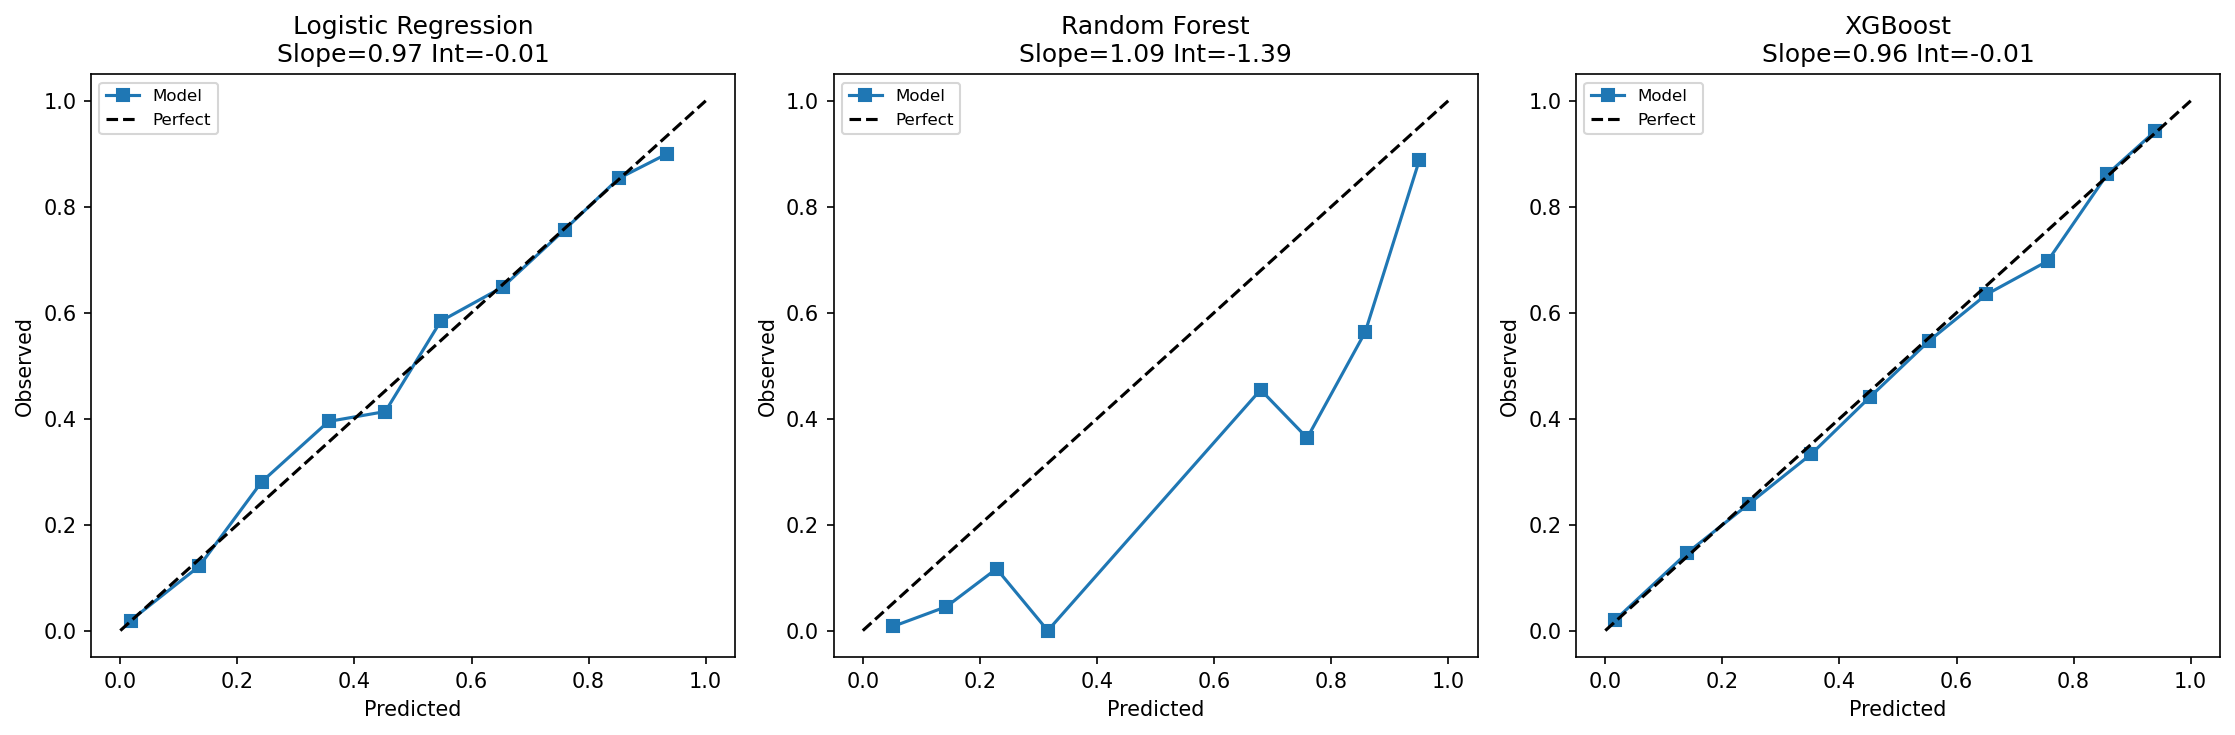

              Model  Slope  Intercept
Logistic Regression  0.973     -0.011
      Random Forest  1.085     -1.389
            XGBoost  0.959     -0.010
Saved: calibration_internal.png, calibration_internal.csv


In [21]:
# Internal Calibration with probability clipping

from sklearn.linear_model import LogisticRegression as CalLR

fig,axes=plt.subplots(1,3,figsize=(15,5))
cal_rows=[]

for idx,(label,model) in enumerate([('Logistic Regression',best_lr),
                                      ('Random Forest',best_rf),
                                      ('XGBoost',best_xgb)]):
    y_prob = CV_PROBS[label]
    # Clip probabilities for numerical stability
    eps = 1e-6
    y_prob_c = np.clip(y_prob, eps, 1-eps)
    log_odds = np.log(y_prob_c/(1-y_prob_c))
    cal_m = CalLR(); cal_m.fit(log_odds.reshape(-1,1),y18)
    slope = cal_m.coef_[0][0]; intercept = cal_m.intercept_[0]
    prob_true,prob_pred = calibration_curve(y18,y_prob,n_bins=10)
    cal_rows.append({'Model':label,
'Slope':round(slope,3),'Intercept':round(intercept,3)})
    ax=axes[idx]
    ax.plot(prob_pred,prob_true,'s-',label='Model')
    ax.plot([0,1],[0,1],'k--',label='Perfect')
    ax.set_title(f'{label}\nSlope={slope:.2f} Int={intercept:.2f}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Observed'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUTS}/calibration_internal.png',dpi=150,bbox_inches='tight')
plt.show()
cal_df=pd.DataFrame(cal_rows)
cal_df.to_csv(f'{OUTPUTS}/calibration_internal.csv',index=False)
print(cal_df.to_string(index=False))
print('Saved: calibration_internal.png, calibration_internal.csv')


In [23]:
# Sensitivity analysis

import statsmodels.api as sm

# Use imputed data for this: fit imputer on full 2018, get complete matrix
imp_full = IterativeImputer(max_iter=10,random_state=42)
X18_imp  = pd.DataFrame(imp_full.fit_transform(X18_raw),
                         columns=FEATURE_NAMES)

X18_sm = sm.add_constant(X18_imp.values.astype(float))
wls_model = sm.WLS(y18.astype(float), X18_sm, weights=w18)
wls_result = wls_model.fit()

# Extract ORs with 95% CI
coef_df = pd.DataFrame({
'feature' :['const']+FEATURE_NAMES,
'coef'    : wls_result.params,
'OR'      : np.exp(wls_result.params),
'CI_lower': np.exp(wls_result.conf_int()[:,0]),
'CI_upper': np.exp(wls_result.conf_int()[:,1]),
'p_value' : wls_result.pvalues
}).round(4)
coef_df.to_csv(f'{OUTPUTS}/survey_weighted_lr_coefficients.csv',index=False)
print('Survey-weighted LR — top predictors by p-value:')
print(coef_df.sort_values('p_value').head(20).to_string(index=False))
print('\nNote: WLS is an approximation; does not account for PSU clustering.')
print('Saved: survey_weighted_lr_coefficients.csv')


Survey-weighted LR — top predictors by p-value:
                feature    coef     OR  CI_lower  CI_upper  p_value
                    age  0.0318 1.0323    1.0281    1.0365   0.0000
                zone_NW -0.0444 0.9566    0.9442    0.9691   0.0000
                hh_size  0.0049 1.0049    1.0034    1.0064   0.0000
       education_Higher -0.0728 0.9298    0.9040    0.9563   0.0000
       hh_head_sex_Male -0.0290 0.9714    0.9586    0.9844   0.0000
         wealth_Richest -0.0302 0.9703    0.9573    0.9834   0.0000
marital_Currently_union  0.2635 1.3015    1.2708    1.3328   0.0000
       marital_Formerly  0.1509 1.1629    1.1089    1.2194   0.0000
          marital_Never -0.4522 0.6362    0.6226    0.6501   0.0000
            contra_know  0.0270 1.0274    1.0129    1.0421   0.0002
                  const -0.0379 0.9628    0.9410    0.9852   0.0012
      education_Primary  0.0243 1.0246    1.0092    1.0403   0.0017
        residence_Rural -0.0197 0.9805    0.9679    0.9932   0.0028


In [24]:
# Identify marital status columns after one-hot encoding
MARITAL_COLS  = [c for c in FEATURE_NAMES if 'marital' in c.lower()]
NON_MARITAL   = [c for c in FEATURE_NAMES if c not in MARITAL_COLS]
print(f'Marital columns excluded in Model B: {MARITAL_COLS}')

X18_nomarital = X18_raw[NON_MARITAL]

# Build same model type as best model, without marital status
if best_label == 'XGBoost':
    clf_b = xgb.XGBClassifier(
        eval_metric='auc', use_label_encoder=False,
        random_state=42, n_jobs=-1)
elif best_label == 'Random Forest':
    clf_b = RandomForestClassifier(random_state=42, n_jobs=-1)
else:
    clf_b = LogisticRegression(max_iter=1000, random_state=42)

pipe_b = Pipeline([
    ('imputer',    IterativeImputer(max_iter=10, random_state=42)),
    ('scaler',     StandardScaler()),
    ('classifier', clf_b)
])

# Fix: use cv_predict_weighted instead of cross_val_predict
y_prob_b = cv_predict_weighted(
    pipe_b, X18_nomarital.values, y18, cv, w18
)

auc_a = roc_auc_score(y18, BEST_PROBS_18)
auc_b = roc_auc_score(y18, y_prob_b)
pr_a  = average_precision_score(y18, BEST_PROBS_18)
pr_b  = average_precision_score(y18, y_prob_b)

sens_df = pd.DataFrame([
    {'Model': 'A_full_predictors',  'AUC-ROC': round(auc_a, 3),
     'PR-AUC': round(pr_a, 3)},
    {'Model': 'B_marital_excluded', 'AUC-ROC': round(auc_b, 3),
     'PR-AUC': round(pr_b, 3)},
    {'Model': 'AUC_drop',           'AUC-ROC': round(auc_a - auc_b, 3),
     'PR-AUC': round(pr_a - pr_b, 3)}
])

print(sens_df.to_string(index=False))
drop = auc_a - auc_b
if drop > 0.05:
    print(f'\n  AUC drop = {drop:.3f} > 0.05')
    print('   Marital status substantially drives predictions.')
    print('   Report Model B results alongside Model A in manuscript.')
else:
    print(f'\n✓  AUC drop = {drop:.3f} ≤ 0.05')
    print('   Marital status is not unduly driving predictions.')

sens_df.to_csv(f'{OUTPUTS}/sensitivity_marital_status.csv', index=False)
print('\nSaved: sensitivity_marital_status.csv')

Marital columns excluded in Model B: ['marital_Currently_union', 'marital_Formerly', 'marital_Never']
             Model  AUC-ROC  PR-AUC
 A_full_predictors    0.963   0.879
B_marital_excluded    0.884   0.684
          AUC_drop    0.080   0.195

  AUC drop = 0.080 > 0.05
   Marital status substantially drives predictions.
   Report Model B results alongside Model A in manuscript.

Saved: sensitivity_marital_status.csv


In [28]:
# Sensitivity births only

print(f'Births-only sample size : {len(y18_births):,}')
print(f'Births-only prevalence  : {y18_births.mean()*100:.1f}%')
print(f'Full outcome prevalence : {y18.mean()*100:.1f}%')

# Build same model type as best model
if best_label == 'XGBoost':
    clf_bo = xgb.XGBClassifier(
        eval_metric='auc', use_label_encoder=False,
        random_state=42, n_jobs=-1)
elif best_label == 'Random Forest':
    clf_bo = RandomForestClassifier(random_state=42, n_jobs=-1)
else:
    clf_bo = LogisticRegression(max_iter=1000, random_state=42)

pipe_bo = Pipeline([
    ('imputer',    IterativeImputer(max_iter=10, random_state=42)),
    ('scaler',     StandardScaler()),
    ('classifier', clf_bo)
])

# Align births-only feature matrix to match FEATURE_NAMES
X18_bo = X18_raw.iloc[:len(y18_births)].copy()

# Fix: use cv_predict_weighted instead of cross_val_predict 
y_prob_bo = cv_predict_weighted(
    pipe_bo, X18_bo.values, y18_births, cv, w18_births
)

auc_full   = roc_auc_score(y18,        BEST_PROBS_18)
auc_births = roc_auc_score(y18_births, y_prob_bo)
pr_full    = average_precision_score(y18,        BEST_PROBS_18)
pr_births  = average_precision_score(y18_births, y_prob_bo)

results_bo = pd.DataFrame([
    {'Outcome': 'Full (incl. currently pregnant)',
     'AUC-ROC': round(auc_full,   3),
     'PR-AUC':  round(pr_full,    3)},
    {'Outcome': 'Births only (excl. currently pregnant)',
     'AUC-ROC': round(auc_births, 3),
     'PR-AUC':  round(pr_births,  3)},
    {'Outcome': 'Difference',
     'AUC-ROC': round(auc_full - auc_births, 3),
     'PR-AUC':  round(pr_full  - pr_births,  3)},
])

print(results_bo.to_string(index=False))

diff = auc_full - auc_births
if diff > 0.05:
    print(f'\n  AUC difference = {diff:.3f} > 0.05')
    print('   Including current pregnancy meaningfully inflates performance.')
    print('   Report births-only results as sensitivity analysis in manuscript.')
else:
    print(f'\n✓  AUC difference = {diff:.3f} ≤ 0.05')
    print('   Including current pregnancy does not meaningfully inflate results.')

results_bo.to_csv(f'{OUTPUTS}/sensitivity_births_only.csv', index=False)
bootstrap_auc = bootstrap_auc_ci
print('\nSaved: sensitivity_births_only.csv')

Births-only sample size : 8,423
Births-only prevalence  : 14.2%
Full outcome prevalence : 18.2%
                               Outcome  AUC-ROC  PR-AUC
       Full (incl. currently pregnant)    0.963   0.879
Births only (excl. currently pregnant)    0.956   0.806
                            Difference    0.008   0.073

✓  AUC difference = 0.008 ≤ 0.05
   Including current pregnancy does not meaningfully inflate results.

Saved: sensitivity_births_only.csv


In [29]:
# Temporal external validation

BEST_MODEL.fit(X18_raw.values, y18,
               classifier__sample_weight=w18)

y24_prob = BEST_MODEL.predict_proba(X24_raw.values)[:,1]
eps = 1e-6; y24_prob_c = np.clip(y24_prob,eps,1-eps)
y24_pred = (y24_prob >= BEST_THRESH).astype(int)

auc24  = roc_auc_score(y24,y24_prob)
pr24   = average_precision_score(y24,y24_prob)
ci24lo,ci24hi = bootstrap_auc(y24,y24_prob)
f124   = f1_score(y24,y24_pred)
acc24  = accuracy_score(y24,y24_pred)
brier24= brier_score_loss(y24,y24_prob)
cm24   = confusion_matrix(y24,y24_pred)
sens24 = cm24[1,1]/(cm24[1,0]+cm24[1,1])
spec24 = cm24[0,0]/(cm24[0,0]+cm24[0,1])

auc18_internal = comp_df.loc[comp_df['Model']==best_label,'AUC-ROC'].values[0]
auc_drop = auc18_internal - auc24

val_df=pd.DataFrame([{
'Dataset':'2024_external',
'AUC-ROC':round(auc24,3),'AUC_CI_95':f'{ci24lo:.3f}–{ci24hi:.3f}',
'PR-AUC':round(pr24,3),
'Threshold':round(BEST_THRESH,3),
'Sensitivity':round(sens24,3),'Specificity':round(spec24,3),
'F1':round(f124,3),'Accuracy':round(acc24,3),'Brier':round(brier24,3),
'AUC_drop':round(auc_drop,3),
'Temporal_instability':'YES' if auc_drop>0.05 else 'NO'}])
val_df.to_csv(f'{OUTPUTS}/temporal_validation_results.csv',index=False)
print(val_df.to_string(index=False))
print('Saved: temporal_validation_results.csv')


      Dataset  AUC-ROC   AUC_CI_95  PR-AUC  Threshold  Sensitivity  Specificity    F1  Accuracy  Brier  AUC_drop Temporal_instability
2024_external    0.966 0.960–0.971   0.857      0.167         0.91        0.933 0.769      0.93  0.041    -0.003                   NO
Saved: temporal_validation_results.csv


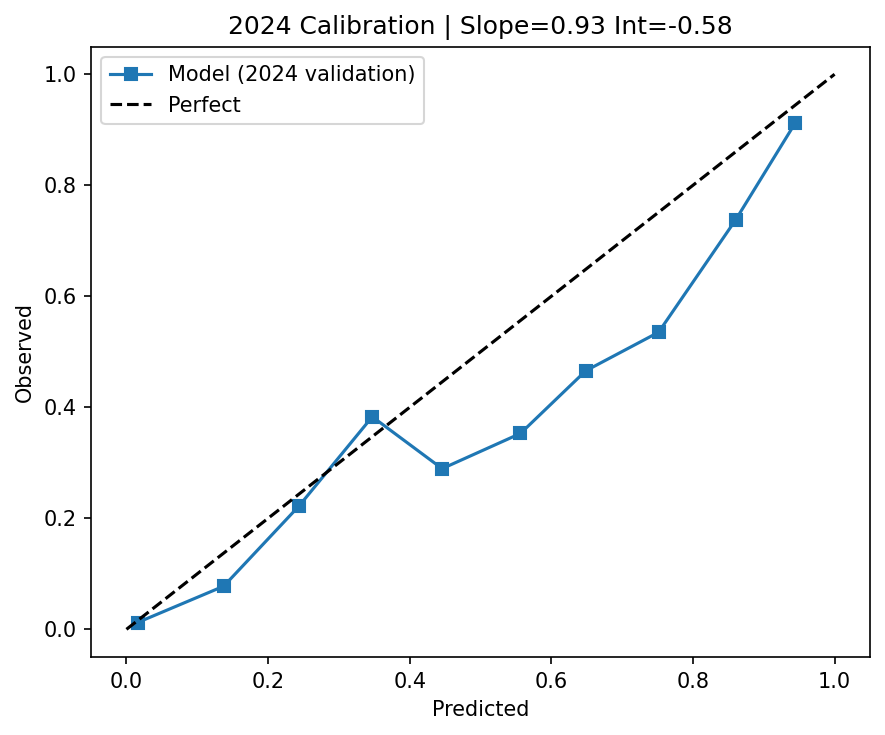

2024 Calibration — Slope:0.933 Int:-0.576
Saved: calibration_2024.png, calibration_2024.csv


In [30]:
# Validation calibration (2024)

eps=1e-6; y24_prob_c=np.clip(y24_prob,eps,1-eps)
log_odds24=np.log(y24_prob_c/(1-y24_prob_c))
cal24=CalLR(); cal24.fit(log_odds24.reshape(-1,1),y24)
slope24=cal24.coef_[0][0]; int24=cal24.intercept_[0]

prob_t,prob_p=calibration_curve(y24,y24_prob,n_bins=10)
fig,ax=plt.subplots(figsize=(6,5))
ax.plot(prob_p,prob_t,'s-',label='Model (2024 validation)')
ax.plot([0,1],[0,1],'k--',label='Perfect')
ax.set_xlabel('Predicted'); ax.set_ylabel('Observed')
ax.set_title(f'2024 Calibration | Slope={slope24:.2f} Int={int24:.2f}')
ax.legend(); plt.tight_layout()
plt.savefig(f'{OUTPUTS}/calibration_2024.png',dpi=150,bbox_inches='tight')
plt.show()
pd.DataFrame([{'Slope':round(slope24,3),'Intercept':round(int24,3)}]).to_csv(
    f'{OUTPUTS}/calibration_2024.csv',index=False)
print(f'2024 Calibration — Slope:{slope24:.3f} Int:{int24:.3f}')
print('Saved: calibration_2024.png, calibration_2024.csv')


subgroup_var category    n  prevalence_%  AUC-ROC
        zone       NC 1597          14.7    0.964
        zone       NE 1661          25.1    0.971
        zone       NW 2253          27.1    0.964
        zone       SE 1066           8.7    0.885
        zone       SS  929          12.4    0.881
        zone       SW  917           7.0    0.915
   residence    Urban 3376           9.1    0.953
   residence    Rural 5047          24.3    0.961


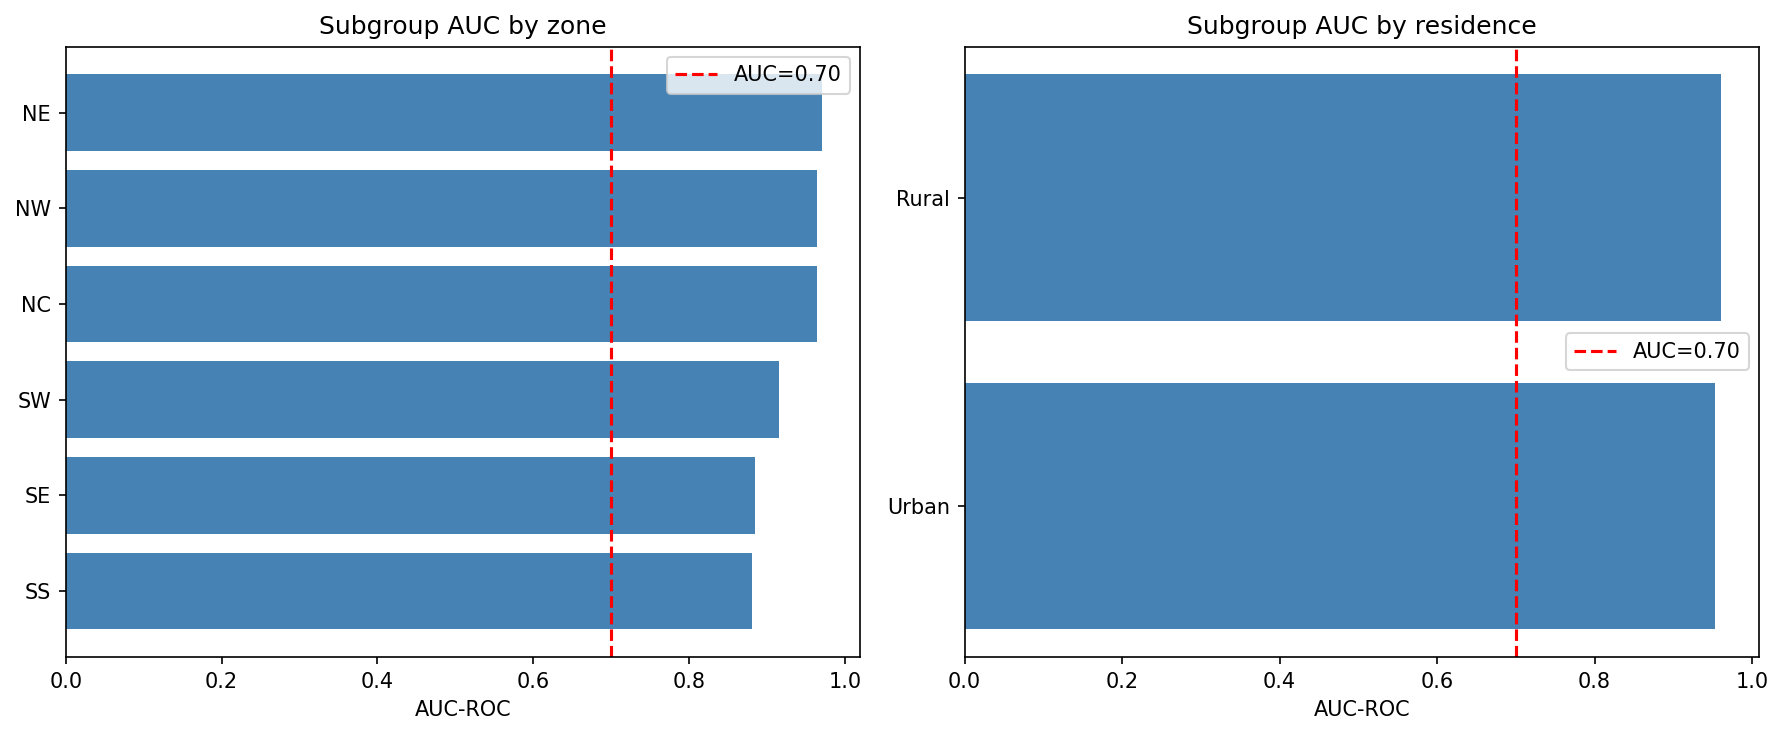

Saved: subgroup_auc.csv, subgroup_auc_plot.png


In [31]:
# Attach predictions back to df18_c

df18_c_eval = df18_c.copy().reset_index(drop=True)
df18_c_eval['y_prob'] = BEST_PROBS_18

subgroup_rows=[]
for sg_var in ['zone','residence']:
    for val in df18_c_eval[sg_var].dropna().unique():
        mask = df18_c_eval[sg_var]==val
        sub  = df18_c_eval[mask]
        if sub['childbearing'].nunique()<2 or len(sub)<30: continue
        auc_sg = roc_auc_score(sub['childbearing'],sub['y_prob'])
        prev_sg = sub['childbearing'].mean()*100
        subgroup_rows.append({
'subgroup_var':sg_var,'category':val,
'n':len(sub),'prevalence_%':round(prev_sg,1),
'AUC-ROC':round(auc_sg,3)})

sg_df=pd.DataFrame(subgroup_rows)
sg_df.to_csv(f'{OUTPUTS}/subgroup_auc.csv',index=False)
print(sg_df.to_string(index=False))

# Plot
fig,axes=plt.subplots(1,2,figsize=(12,5))
for i,sgv in enumerate(['zone','residence']):
    sub=sg_df[sg_df['subgroup_var']==sgv].sort_values('AUC-ROC')
    axes[i].barh(sub['category'],sub['AUC-ROC'],color='steelblue')
    axes[i].axvline(0.7,color='red',linestyle='--',label='AUC=0.70')
    axes[i].set_xlabel('AUC-ROC'); axes[i].set_title(f'Subgroup AUC by {sgv}')
    axes[i].legend()
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/subgroup_auc_plot.png',dpi=150,bbox_inches='tight')
plt.show()
print('Saved: subgroup_auc.csv, subgroup_auc_plot.png')


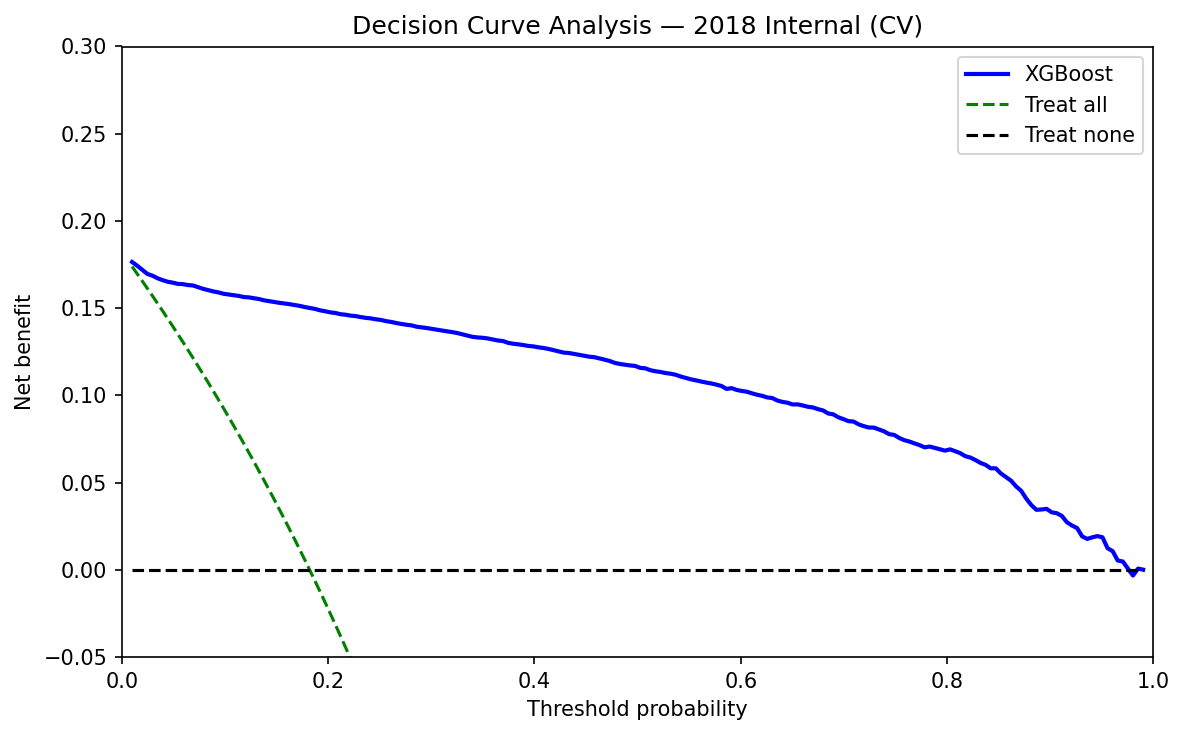

Saved: dca_internal.png, dca_results.csv


In [32]:
# Decision curve analysis

def net_benefit(y_true, y_prob, threshold):
    n = len(y_true)
    y_pred = (y_prob >= threshold).astype(int)
    tp = ((y_pred==1)&(y_true==1)).sum()
    fp = ((y_pred==1)&(y_true==0)).sum()
    nb = tp/n - fp/n * (threshold/(1-threshold+1e-9))
    return nb

thresholds = np.linspace(0.01, 0.99, 200)

nb_best  = [net_benefit(y18, BEST_PROBS_18, t) for t in thresholds]
nb_all   = [y18.mean() - (1-y18.mean())*(t/(1-t+1e-9)) for t in thresholds]
nb_none  = [0]*len(thresholds)

fig,ax = plt.subplots(figsize=(8,5))
ax.plot(thresholds, nb_best,  'b-',  label=f'{best_label}', linewidth=2)
ax.plot(thresholds, nb_all,   'g--', label='Treat all',     linewidth=1.5)
ax.plot(thresholds, nb_none,  'k--', label='Treat none',    linewidth=1.5)
ax.set_xlim([0,1]); ax.set_ylim([-0.05,0.3])
ax.set_xlabel('Threshold probability'); ax.set_ylabel('Net benefit')
ax.set_title('Decision Curve Analysis — 2018 Internal (CV)')
ax.legend(); plt.tight_layout()
plt.savefig(f'{OUTPUTS}/dca_internal.png',dpi=150,bbox_inches='tight')
plt.show()

dca_df=pd.DataFrame({'threshold':thresholds,'NB_model':nb_best,
'NB_treat_all':nb_all,'NB_treat_none':nb_none})
dca_df.to_csv(f'{OUTPUTS}/dca_results.csv',index=False)
print('Saved: dca_internal.png, dca_results.csv')


In [33]:
# Fit on full 2018 data; extract the final classifier step for SHAP

BEST_MODEL.fit(X18_raw.values, y18)

# Get imputed+scaled data for SHAP (use the Pipeline's transform steps)
X18_transformed = BEST_MODEL[:-1].transform(X18_raw.values)
X24_transformed = BEST_MODEL[:-1].transform(X24_raw.values)

clf_step = BEST_MODEL.named_steps['classifier']
background = shap.sample(X18_transformed, 500, random_state=42)

if best_label in ['Random Forest','XGBoost']:
    explainer = shap.TreeExplainer(clf_step, background)
else:
    explainer = shap.LinearExplainer(clf_step, background)

sv18 = explainer.shap_values(X18_transformed)
if isinstance(sv18,list): sv18=sv18[1]
sv24 = explainer.shap_values(X24_transformed)
if isinstance(sv24,list): sv24=sv24[1]

pd.DataFrame(sv18,columns=FEATURE_NAMES).to_csv(f'{OUTPUTS}/shap_2018.csv',index=False)
pd.DataFrame(sv24,columns=FEATURE_NAMES).to_csv(f'{OUTPUTS}/shap_2024.csv',index=False)
print(f'SHAP shapes — 2018:{sv18.shape} | 2024:{sv24.shape}')
print('Saved: shap_2018.csv, shap_2024.csv')


100%|===================| 7993/7995 [02:22<00:00]        

SHAP shapes — 2018:(8423, 30) | 2024:(7995, 30)
Saved: shap_2018.csv, shap_2024.csv


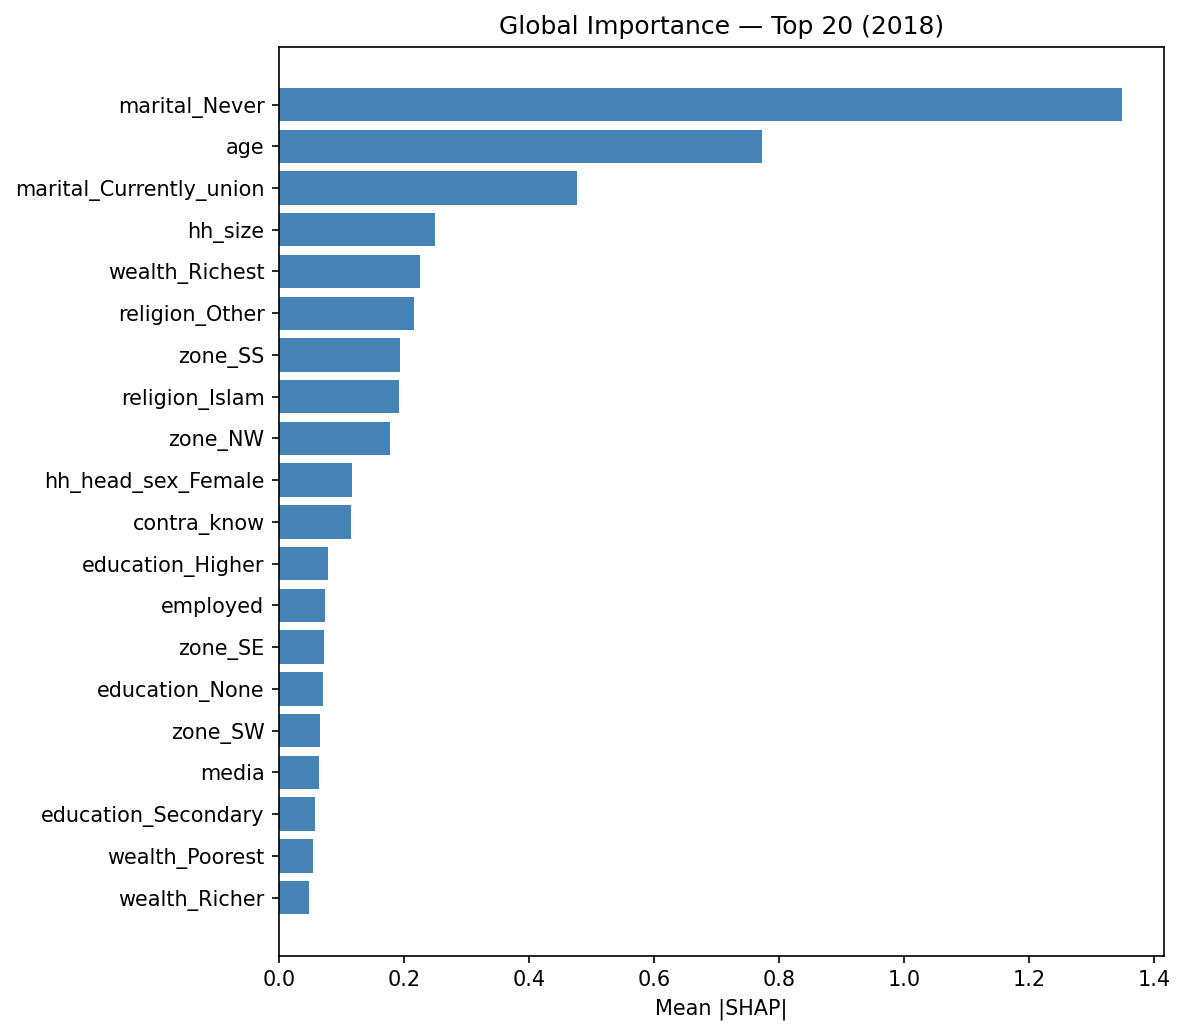

Saved: global_shap_importance.csv, global_shap.png


In [34]:
# Global feature importance

imp_df=pd.DataFrame({'feature':FEATURE_NAMES,
'mean_abs_shap':np.abs(sv18).mean(axis=0)}).sort_values(
'mean_abs_shap',ascending=False).reset_index(drop=True)
imp_df.to_csv(f'{OUTPUTS}/global_shap_importance.csv',index=False)

top20=imp_df.head(20)
fig,ax=plt.subplots(figsize=(8,7))
ax.barh(top20['feature'][::-1],top20['mean_abs_shap'][::-1],color='steelblue')
ax.set_xlabel('Mean |SHAP|'); ax.set_title('Global Importance — Top 20 (2018)')
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/global_shap.png',dpi=150,bbox_inches='tight')
plt.show()
print('Saved: global_shap_importance.csv, global_shap.png')


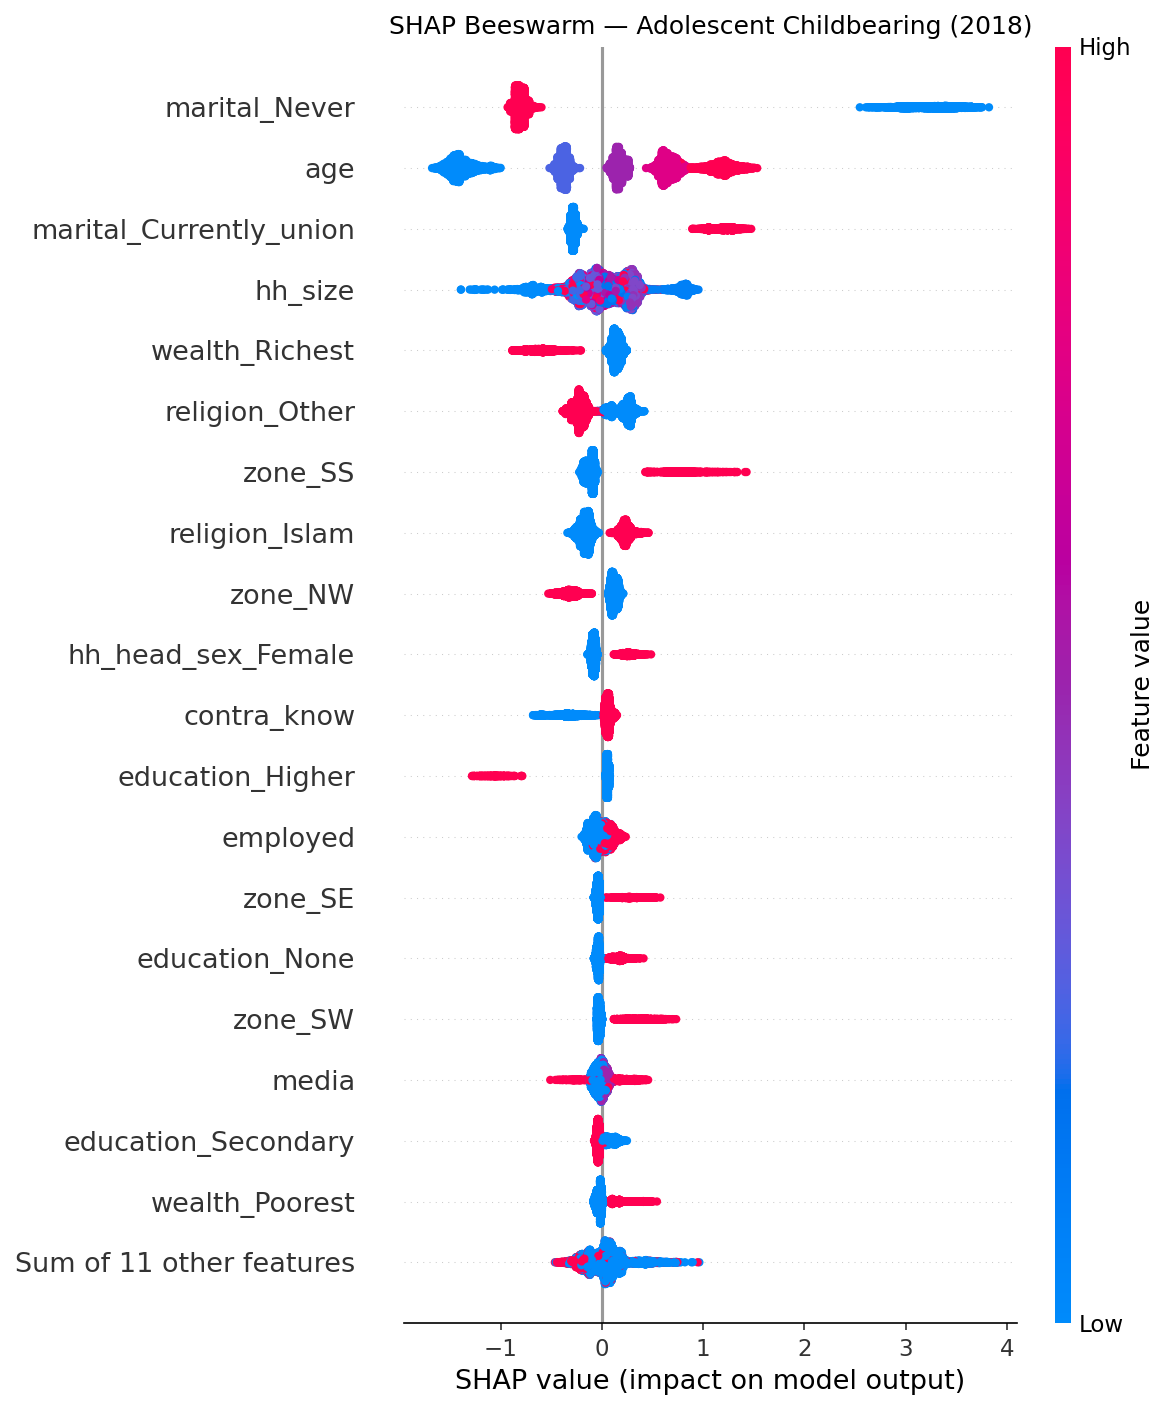

Saved: shap_beeswarm.png


In [35]:
# SHAP Beeswarm plot

ev = explainer.expected_value
if isinstance(ev,list): ev=ev[1]
shap_exp = shap.Explanation(values=sv18,base_values=ev,
    data=X18_transformed,feature_names=FEATURE_NAMES)
plt.figure(figsize=(10,8))
shap.plots.beeswarm(shap_exp,max_display=20,show=False)
plt.title('SHAP Beeswarm — Adolescent Childbearing (2018)')
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/shap_beeswarm.png',dpi=150,bbox_inches='tight')
plt.show()
print('Saved: shap_beeswarm.png')


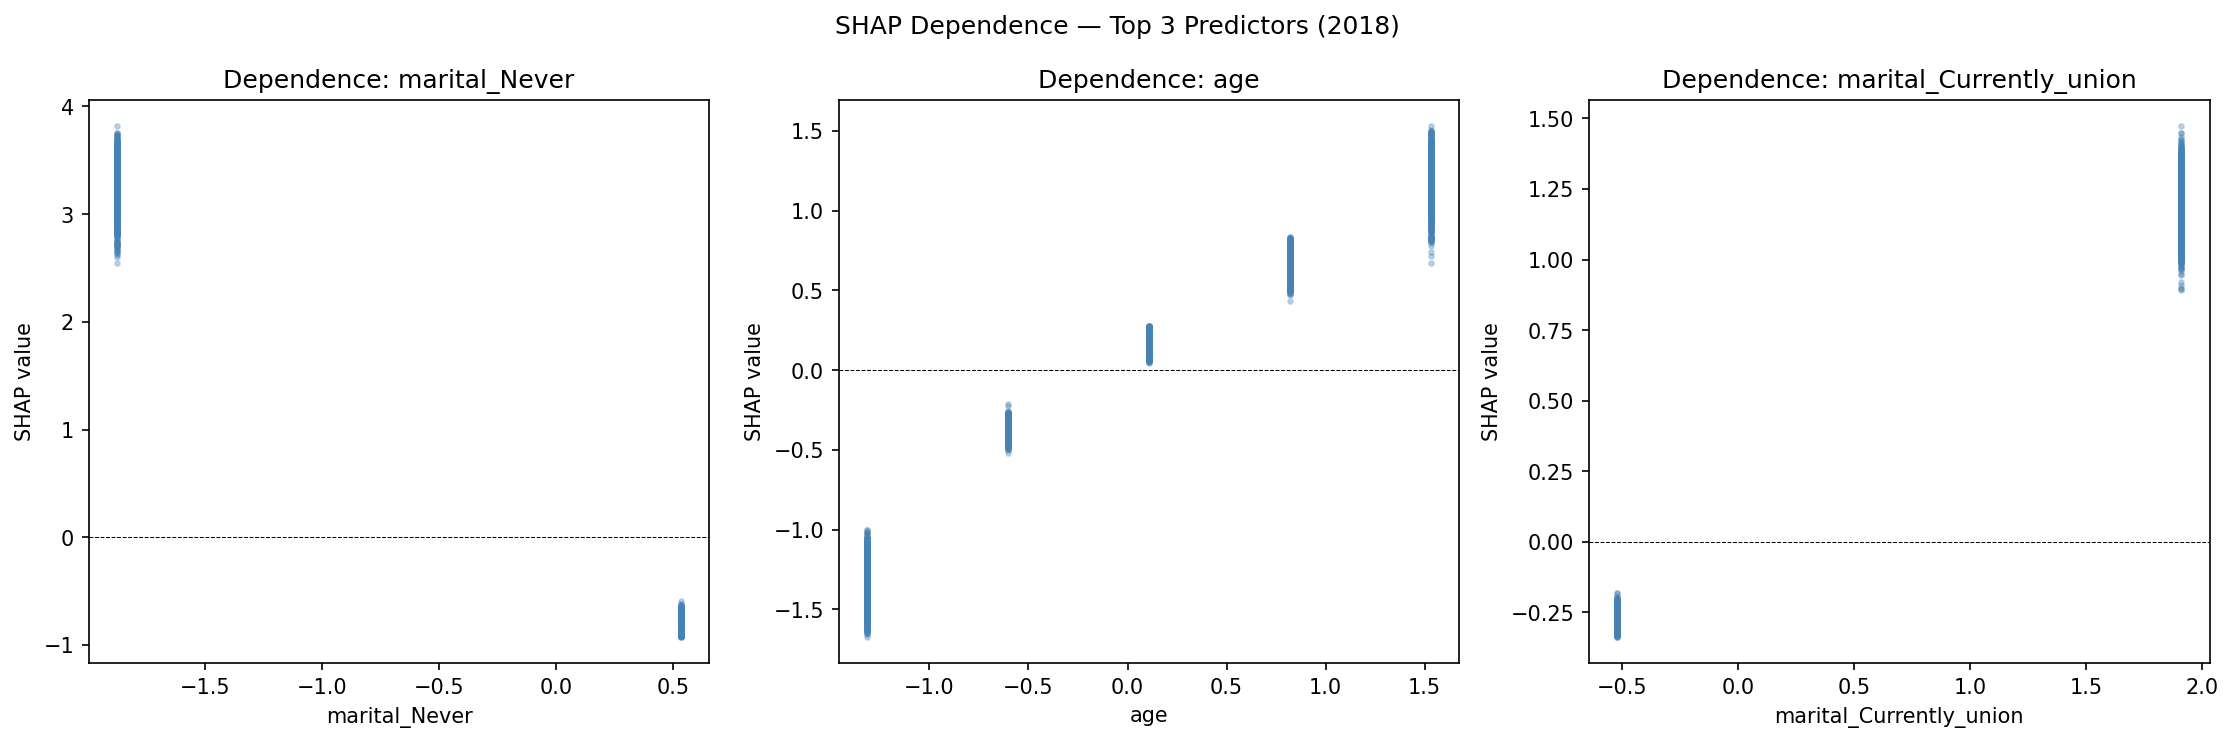

Saved: shap_dependence.png


In [36]:
# SHAP dependences plots – Top 3 predictors

top3=imp_df['feature'].head(3).tolist()
fig,axes=plt.subplots(1,3,figsize=(15,5))
for i,feat in enumerate(top3):
    fi=FEATURE_NAMES.index(feat)
    axes[i].scatter(X18_transformed[:,fi],sv18[:,fi],alpha=0.3,s=5,c='steelblue')
    axes[i].axhline(0,color='k',linewidth=0.5,linestyle='--')
    axes[i].set_xlabel(feat); axes[i].set_ylabel('SHAP value')
    axes[i].set_title(f'Dependence: {feat}')
plt.suptitle('SHAP Dependence — Top 3 Predictors (2018)')
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/shap_dependence.png',dpi=150,bbox_inches='tight')
plt.show()
print('Saved: shap_dependence.png')


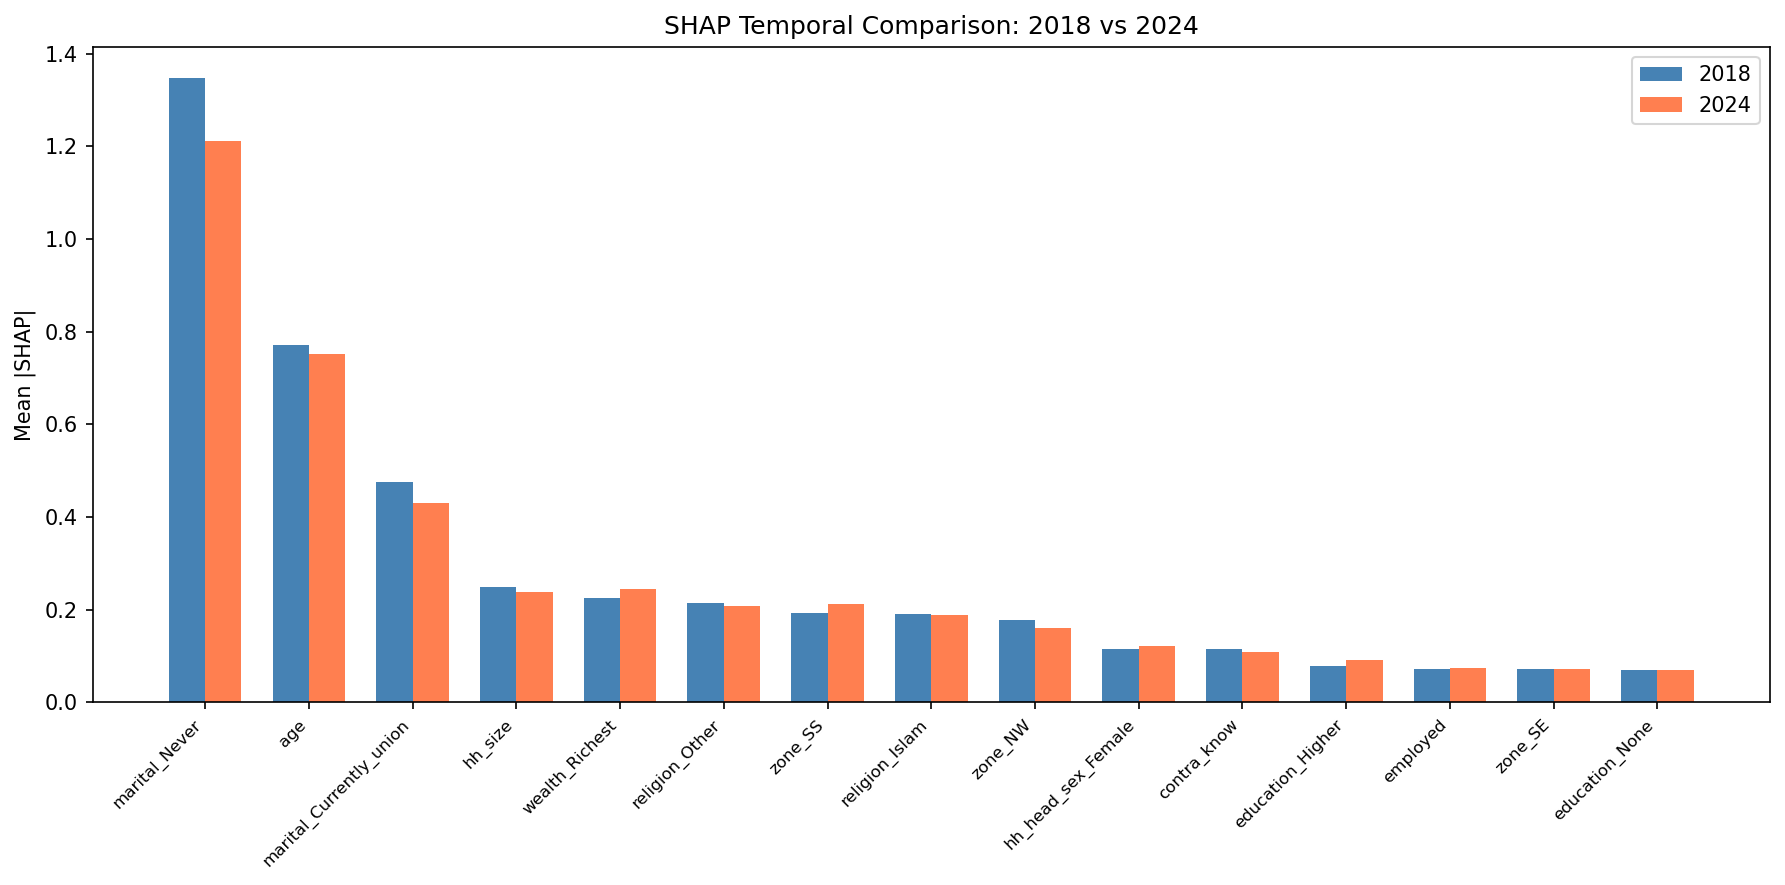

Saved: shap_temporal.csv, shap_temporal.png


In [37]:
# Temporal SHAP comparison (2018 vs 2024)

m18=np.abs(sv18).mean(axis=0)
m24=np.abs(sv24).mean(axis=0)
tmp_df=pd.DataFrame({'feature':FEATURE_NAMES,
'shap_2018':m18,'shap_2024':m24,
'change':m24-m18}).sort_values('shap_2018',ascending=False).head(15)
tmp_df.to_csv(f'{OUTPUTS}/shap_temporal.csv',index=False)

x=np.arange(len(tmp_df)); w=0.35
fig,ax=plt.subplots(figsize=(12,6))
ax.bar(x-w/2,tmp_df['shap_2018'],w,label='2018',color='steelblue')
ax.bar(x+w/2,tmp_df['shap_2024'],w,label='2024',color='coral')
ax.set_xticks(x); ax.set_xticklabels(tmp_df['feature'],rotation=45,ha='right',fontsize=8)
ax.set_ylabel('Mean |SHAP|'); ax.set_title('SHAP Temporal Comparison: 2018 vs 2024')
ax.legend(); plt.tight_layout()
plt.savefig(f'{OUTPUTS}/shap_temporal.png',dpi=150,bbox_inches='tight')
plt.show()
print('Saved: shap_temporal.csv, shap_temporal.png')


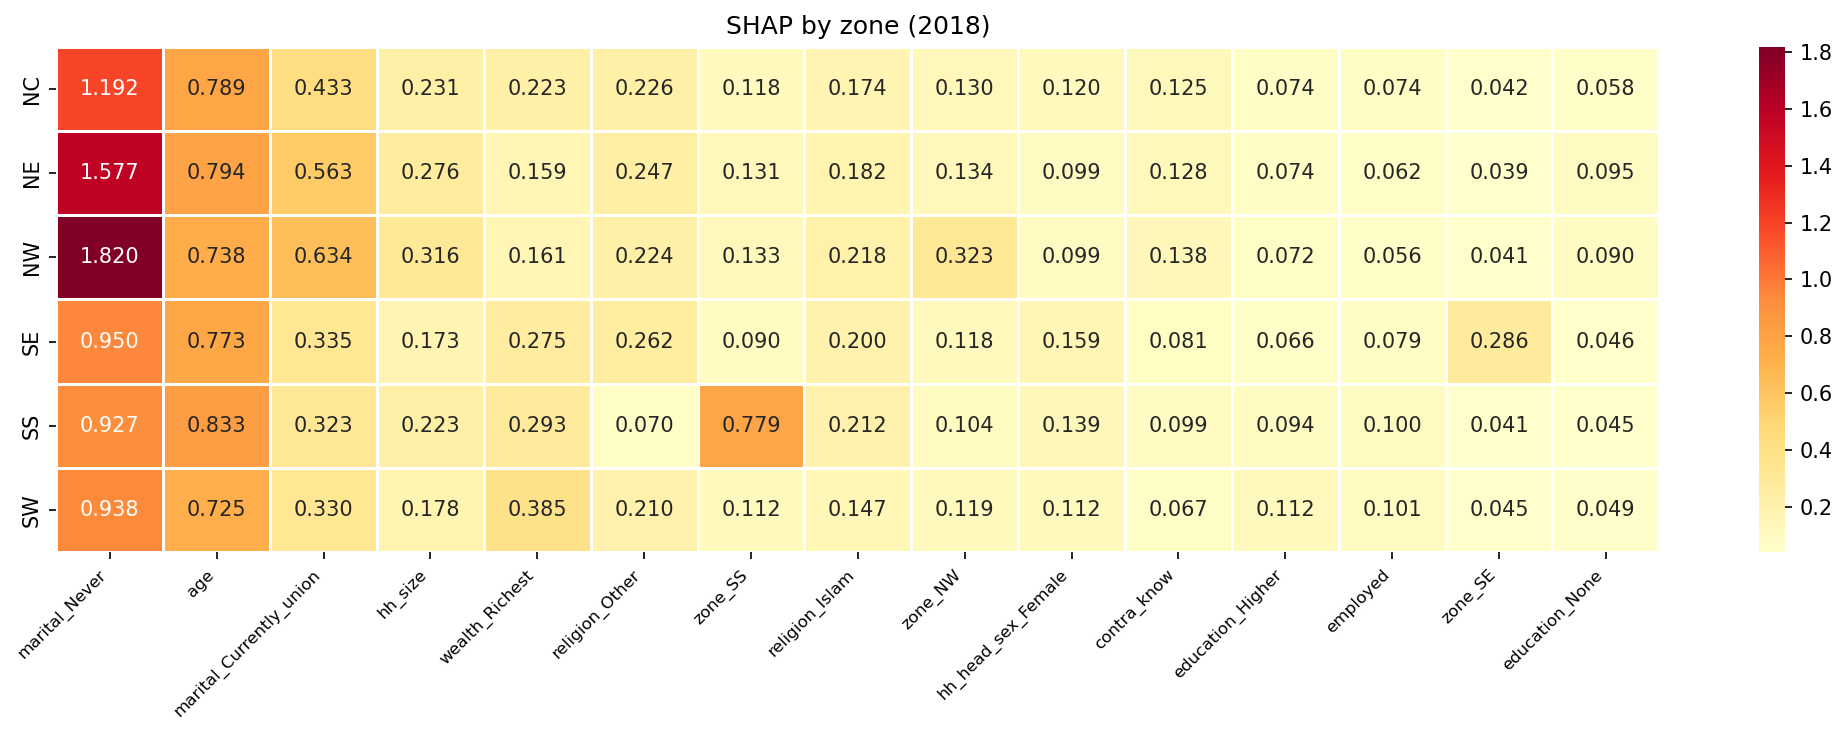

Saved: shap_by_zone.csv, shap_heatmap_zone.png


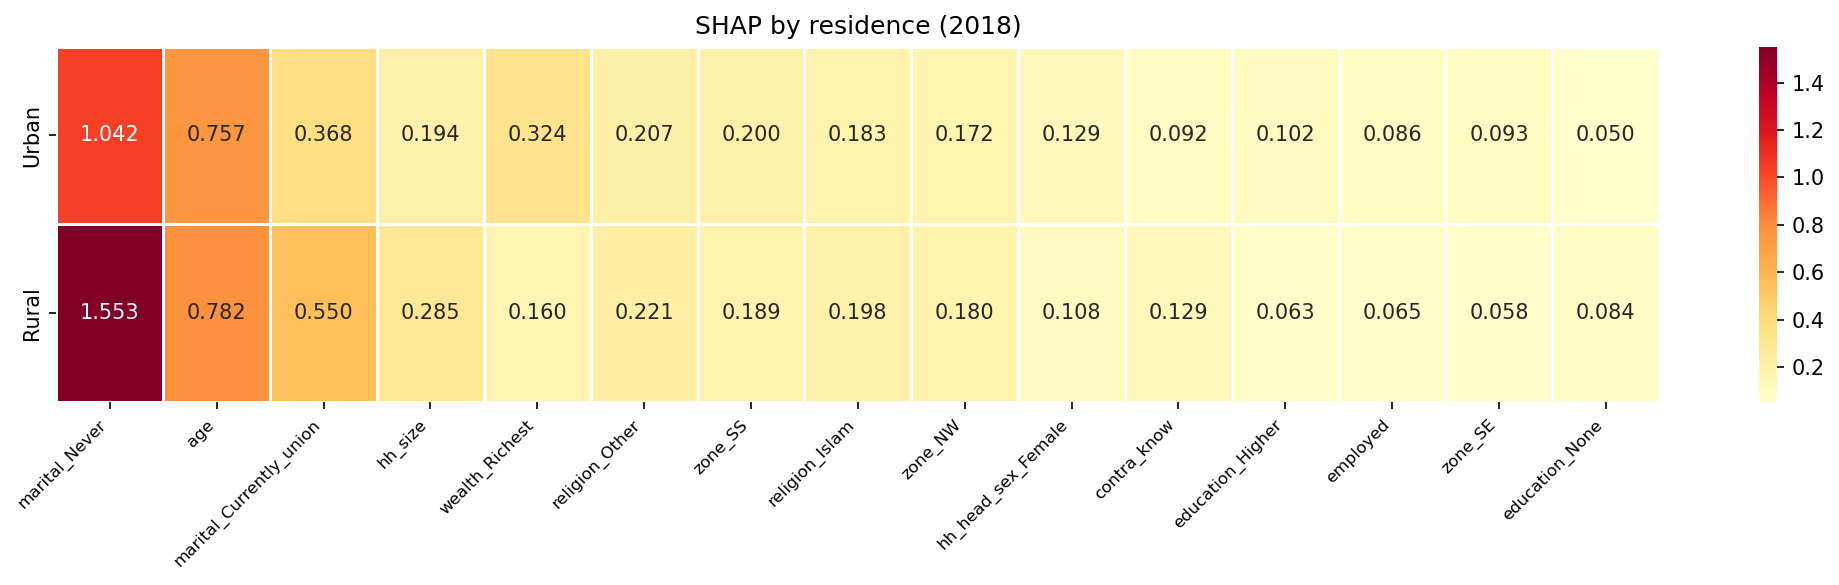

Saved: shap_by_residence.csv, shap_heatmap_residence.png


In [38]:
# Subgroup SHAP by zone and residence

df18_c_shap = df18_c.copy().reset_index(drop=True)

for sg_var, fname in [('zone','zone'),('residence','residence')]:
    sg_shap={}
    for val in df18_c_shap[sg_var].dropna().unique():
        mask = (df18_c_shap[sg_var]==val).values  # simple boolean mask
        if mask.sum()>0:
            sg_shap[val] = np.abs(sv18[mask,:]).mean(axis=0)
    sg_df=pd.DataFrame(sg_shap,index=FEATURE_NAMES).T
    top15_feats=imp_df['feature'].head(15).tolist()
    sg_df=sg_df[[c for c in top15_feats if c in sg_df.columns]]
    sg_df.to_csv(f'{OUTPUTS}/shap_by_{fname}.csv')
    fig,ax=plt.subplots(figsize=(14,4 if sg_var=='residence' else 5))
    sns.heatmap(sg_df,annot=True,fmt='.3f',cmap='YlOrRd',linewidths=0.5,ax=ax)
    ax.set_title(f'SHAP by {sg_var} (2018)'); plt.xticks(rotation=45,ha='right',fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{OUTPUTS}/shap_heatmap_{fname}.png',dpi=150,bbox_inches='tight')
    plt.show()
    print(f'Saved: shap_by_{fname}.csv, shap_heatmap_{fname}.png')


In [39]:
# Save full results workbook

with pd.ExcelWriter(f'{OUTPUTS}/FULL_RESULTS_v2.xlsx') as w:
    comp_df.to_excel(w,sheet_name='Internal_Validation',index=False)
    val_df.to_excel(w,sheet_name='Temporal_Validation',index=False)
    cal_df.to_excel(w,sheet_name='Calibration_Internal',index=False)
    pd.DataFrame([{'Slope':slope24,'Intercept':int24}]).to_excel(
        w,sheet_name='Calibration_2024',index=False)
    strat_df.to_excel(w,sheet_name='Stratified_Prevalence',index=False)
    chi2_df.to_excel(w,sheet_name='Bivariate_Chi2',index=False)
    imp_df.to_excel(w,sheet_name='Global_SHAP',index=False)
    tmp_df.to_excel(w,sheet_name='Temporal_SHAP',index=False)
    audit.to_excel(w,sheet_name='Harmonisation_Audit',index=False)
    vif_df.to_excel(w,sheet_name='VIF_Check',index=False)
    coef_df.to_excel(w,sheet_name='Weighted_LR_Sensitivity',index=False)
    sens_df.to_excel(w,sheet_name='Marital_Sensitivity',index=False)
    sg_df.to_excel(w,sheet_name='Subgroup_AUC',index=False)
    dca_df.to_excel(w,sheet_name='DCA',index=False)

print('='*55)
print(' ANALYSIS COMPLETE — Version 2.0')
print('='*55)
print(f'All outputs saved to: {OUTPUTS}')
print('\nAll files:')
for f in sorted(os.listdir(OUTPUTS)): print(f'  {f}')


 ANALYSIS COMPLETE — Version 2.0
All outputs saved to: outputs

All files:
  ADOL_CHILDBEARING_RESULTS_20260528_1300.zip
  ADOL_CHILDBEARING_RESULTS_20260528_2040.zip
  ADOL_CHILDBEARING_RESULTS_20260606_0735.zip
  FULL_RESULTS_v2.xlsx
  Table1_Sociodemographic.xlsx
  X18_raw.csv
  X24_raw.csv
  best_lr.pkl
  best_model.pkl
  best_model_label.txt
  best_rf.pkl
  best_thresh.txt
  best_xgb.pkl
  bivariate_chi2_2018.csv
  calibration_2024.csv
  calibration_2024.png
  calibration_internal.csv
  calibration_internal.png
  cv_probs.pkl
  dca_internal.png
  dca_results.csv
  global_shap.png
  global_shap_importance.csv
  harmonisation_audit.csv
  model_comparison_internal.csv
  sensitivity_births_only.csv
  sensitivity_marital_status.csv
  shap_2018.csv
  shap_2024.csv
  shap_beeswarm.png
  shap_by_residence.csv
  shap_by_zone.csv
  shap_dependence.png
  shap_heatmap_residence.png
  shap_heatmap_zone.png
  shap_temporal.csv
  shap_temporal.png
  stratified_prevalence.csv
  subgroup_auc.csv
 

In [40]:
# Consolidate all results into 1 zip file

import zipfile
import os
import shutil
from datetime import datetime

timestamp = datetime.now().strftime('%Y%m%d_%H%M')
zip_name  = f'ADOL_CHILDBEARING_RESULTS_{timestamp}.zip'
zip_path  = os.path.join(OUTPUTS, zip_name)

# Files to include
EXPECTED_FILES = [
    # Data
    'harmonisation_audit.csv',
    'X18_raw.csv',
    'X24_raw.csv',
    # Descriptive
    'stratified_prevalence.csv',
    'bivariate_chi2_2018.csv',
    'Table1_Sociodemographic.xlsx',
    # Multicollinearity
    'vif_check.csv',
    # Model comparison
    'model_comparison_internal.csv',
    # Calibration
    'calibration_internal.png',
    'calibration_internal.csv',
    'calibration_2024.png',
    'calibration_2024.csv',
    # Temporal validation
    'temporal_validation_results.csv',
    # Sensitivity analyses
    'sensitivity_marital_status.csv',
    'sensitivity_births_only.csv',
    'survey_weighted_lr_coefficients.csv',
    # Subgroup
    'subgroup_auc.csv',
    'subgroup_auc_plot.png',
    # DCA
    'dca_results.csv',
    'dca_internal.png',
    # SHAP
    'global_shap_importance.csv',
    'global_shap.png',
    'shap_beeswarm.png',
    'shap_dependence.png',
    'shap_temporal.csv',
    'shap_temporal.png',
    'shap_by_zone.csv',
    'shap_heatmap_zone.png',
    'shap_by_residence.csv',
    'shap_heatmap_residence.png',
    # Models
    'best_model.pkl',
    'best_model_label.txt',
    'best_thresh.txt',
    # Master workbook
    'FULL_RESULTS_v2.xlsx',
]

found   = []
missing = []

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in EXPECTED_FILES:
        fpath = os.path.join(OUTPUTS, fname)
        if os.path.exists(fpath):
            zf.write(fpath, arcname=fname)
            found.append(fname)
        else:
            missing.append(fname)

    # Also add the notebook itself if found
    for f in os.listdir('.'):
        if f.endswith('.ipynb'):
            zf.write(f, arcname=f'notebook_{f}')
            found.append(f)

print('=' * 55)
print(f'ZIP FILE CREATED: {zip_name}')
print(f'Location        : {zip_path}')
print(f'Files included  : {len(found)}')
print('=' * 55)

if missing:
    print(f'\nFiles not found (skipped): {len(missing)}')
    for m in missing:
        print(f'  - {m}')
else:
    print('\nAll expected files included.')

print(f'\nFull path to download:')
print(f'  {os.path.abspath(zip_path)}')

ZIP FILE CREATED: ADOL_CHILDBEARING_RESULTS_20260611_1201.zip
Location        : outputs\ADOL_CHILDBEARING_RESULTS_20260611_1201.zip
Files included  : 40

All expected files included.

Full path to download:
  C:\Users\USER\outputs\ADOL_CHILDBEARING_RESULTS_20260611_1201.zip


In [41]:
import os
OUTPUTS = 'outputs'  # adjust if your path is different
os.makedirs(OUTPUTS, exist_ok=True)
print(f'Outputs folder: {os.path.abspath(OUTPUTS)}')

Outputs folder: C:\Users\USER\outputs


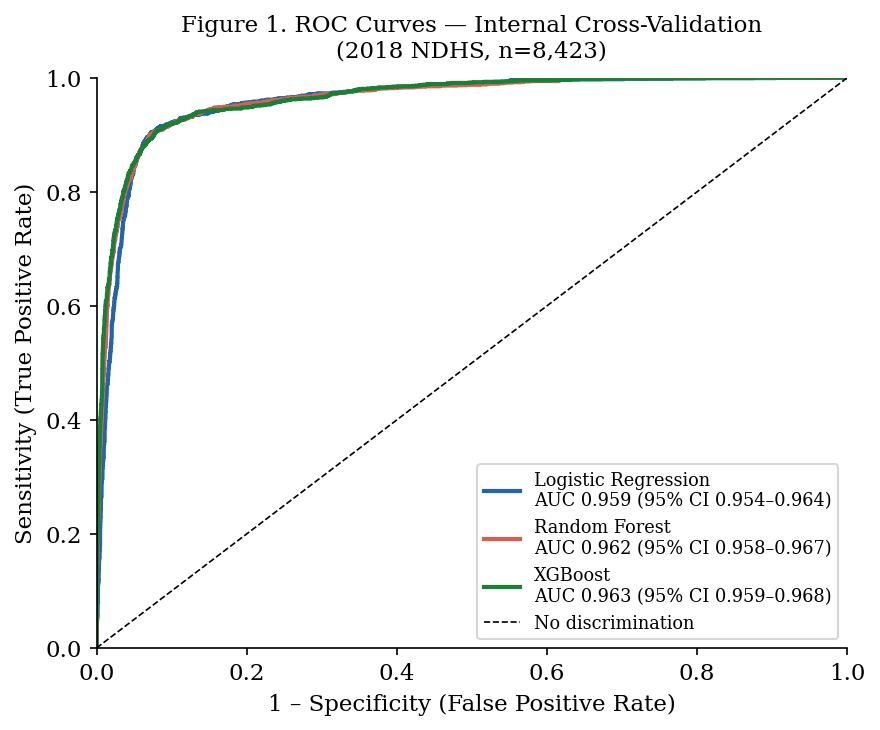

Saved: Figure1_ROC_Curves.tiff and Figure1_ROC_Curves.png


In [42]:
# Figure 1 extraction

import matplotlib.pyplot as plt
import matplotlib
from sklearn.metrics import roc_curve
matplotlib.rcParams.update({'font.family':'serif','font.size':11})

fig, ax = plt.subplots(figsize=(6,5))
colors = ['#2166AC','#D6604D','#1A7F37']
labels = ['Logistic Regression','Random Forest','XGBoost']
probs  = [CV_PROBS['Logistic Regression'],
          CV_PROBS['Random Forest'],
          CV_PROBS['XGBoost']]
aucs   = [0.959, 0.962, 0.963]
cis    = ['(95% CI 0.954–0.964)',
          '(95% CI 0.958–0.967)',
          '(95% CI 0.959–0.968)']

for prob, label, auc, ci, color in zip(probs,labels,aucs,cis,colors):
    fpr, tpr, _ = roc_curve(y18, prob)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{label}\nAUC {auc} {ci}')

ax.plot([0,1],[0,1],'k--', linewidth=0.8, label='No discrimination')
ax.set_xlabel('1 – Specificity (False Positive Rate)', fontsize=11)
ax.set_ylabel('Sensitivity (True Positive Rate)', fontsize=11)
ax.set_title('Figure 1. ROC Curves — Internal Cross-Validation\n(2018 NDHS, n=8,423)',
             fontsize=11, pad=10)
ax.legend(loc='lower right', fontsize=8.5)
ax.set_xlim([0,1]); ax.set_ylim([0,1])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/Figure1_ROC_Curves.tiff',
            dpi=300, bbox_inches='tight', format='tiff')
plt.savefig(f'{OUTPUTS}/Figure1_ROC_Curves.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: Figure1_ROC_Curves.tiff and Figure1_ROC_Curves.png')


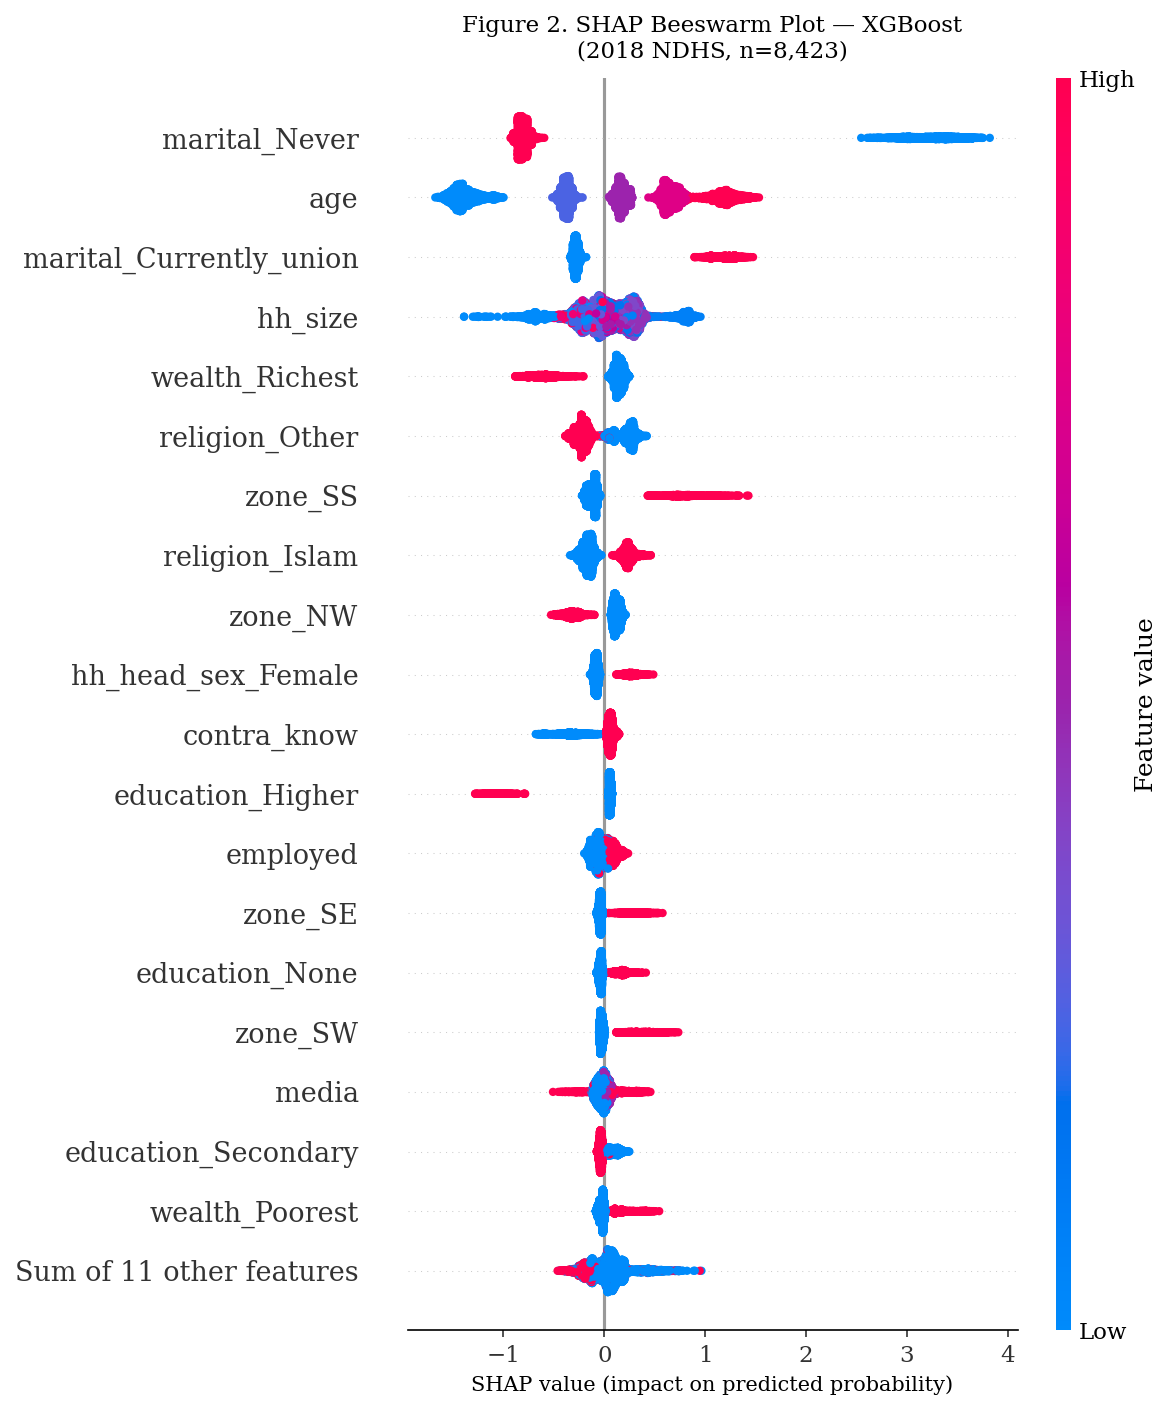

Saved: Figure2_SHAP_Beeswarm.tiff and Figure2_SHAP_Beeswarm.png


In [43]:
# Figure 2 extraction

import shap, matplotlib
matplotlib.rcParams.update({'font.family':'serif','font.size':10})

ev = explainer.expected_value
if isinstance(ev, list):
    ev = ev[1]

shap_exp = shap.Explanation(
    values       = sv18,
    base_values  = ev,
    data         = X18_transformed,
    feature_names= FEATURE_NAMES
)

plt.figure(figsize=(8,7))
shap.plots.beeswarm(shap_exp, max_display=20, show=False)
plt.title('Figure 2. SHAP Beeswarm Plot — XGBoost\n(2018 NDHS, n=8,423)',
          fontsize=11, pad=10)
plt.xlabel('SHAP value (impact on predicted probability)', fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/Figure2_SHAP_Beeswarm.tiff',
            dpi=300, bbox_inches='tight', format='tiff')
plt.savefig(f'{OUTPUTS}/Figure2_SHAP_Beeswarm.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: Figure2_SHAP_Beeswarm.tiff and Figure2_SHAP_Beeswarm.png')




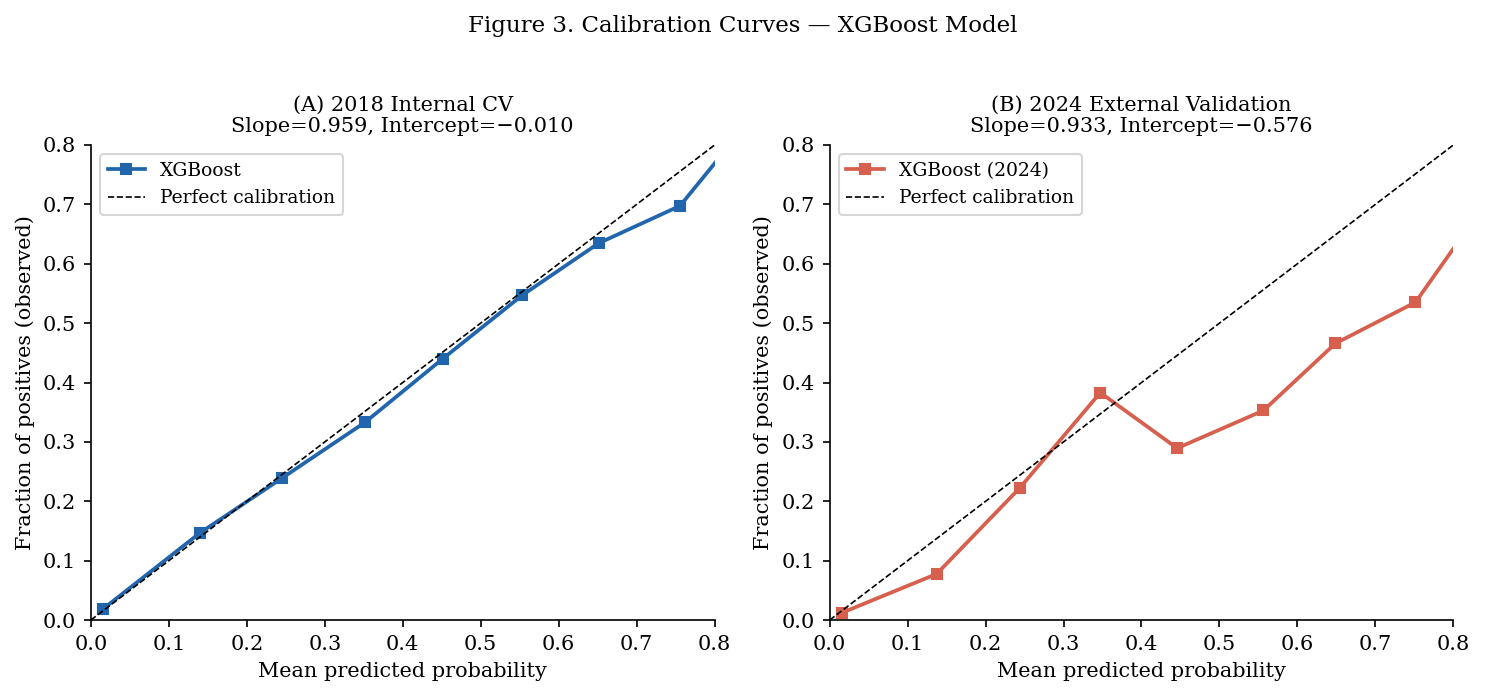

Saved: Figure3_Calibration.tiff and Figure3_Calibration.png


In [44]:
# Figure 3 extraction

from sklearn.calibration import calibration_curve
import matplotlib
matplotlib.rcParams.update({'font.family':'serif','font.size':10})

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# Panel A: 2018 internal
prob_true18, prob_pred18 = calibration_curve(y18, BEST_PROBS_18, n_bins=10)
axes[0].plot(prob_pred18, prob_true18, 's-', color='#2166AC',
             linewidth=1.8, markersize=5, label='XGBoost')
axes[0].plot([0,1],[0,1],'k--', linewidth=0.8, label='Perfect calibration')
axes[0].set_xlabel('Mean predicted probability', fontsize=10)
axes[0].set_ylabel('Fraction of positives (observed)', fontsize=10)
axes[0].set_title('(A) 2018 Internal CV\nSlope=0.959, Intercept=−0.010',
                  fontsize=10)
axes[0].legend(fontsize=9)
axes[0].set_xlim([0,0.8]); axes[0].set_ylim([0,0.8])
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Panel B: 2024 external
prob_true24, prob_pred24 = calibration_curve(y24, y24_prob, n_bins=10)
axes[1].plot(prob_pred24, prob_true24, 's-', color='#D6604D',
             linewidth=1.8, markersize=5, label='XGBoost (2024)')
axes[1].plot([0,1],[0,1],'k--', linewidth=0.8, label='Perfect calibration')
axes[1].set_xlabel('Mean predicted probability', fontsize=10)
axes[1].set_ylabel('Fraction of positives (observed)', fontsize=10)
axes[1].set_title('(B) 2024 External Validation\nSlope=0.933, Intercept=−0.576',
                  fontsize=10)
axes[1].legend(fontsize=9)
axes[1].set_xlim([0,0.8]); axes[1].set_ylim([0,0.8])
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('Figure 3. Calibration Curves — XGBoost Model',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/Figure3_Calibration.tiff',
            dpi=300, bbox_inches='tight', format='tiff')
plt.savefig(f'{OUTPUTS}/Figure3_Calibration.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: Figure3_Calibration.tiff and Figure3_Calibration.png')

